In [53]:
from pathlib import Path
from typing import List, Dict, Optional, Tuple
import csv
import re
from datetime import datetime, timedelta
import pandas as pd

In [21]:

from pathlib import Path

# --- Configuration ---
BASE_FOLDER = Path(".")                 # change if your working directory differs
SUBFOLDER_NAME = "Helmert_files"        # your folder holding the .OUT files
INPUT_EXTS = {".out"}           # we handle case-insensitive via .lower()

def list_helmert_files(base_folder: Path, subfolder_name: str = "Helmert_files"):
    input_dir = base_folder / subfolder_name
    if not input_dir.exists():
        print(f"⚠️ Folder not found: {input_dir.resolve()}")
        return []
    files = [p for p in input_dir.rglob("*") if p.suffix.lower() in INPUT_EXTS]
    files_sorted = sorted(files, key=lambda x: x.name)
    print(f"Found {len(files_sorted)} file(s) in {input_dir.resolve()}")
    for p in files_sorted[:10]:
        print(f"  - {p.relative_to(base_folder)}")
    if len(files_sorted) > 10:
        print("  ... (showing first 10)")
    return files_sorted

# Execute file discovery
FILES = list_helmert_files(BASE_FOLDER, SUBFOLDER_NAME)


Found 184 file(s) in C:\Users\LHansen\OneDrive - Land Information New Zealand\2025\Python\Scripts\IGG_sites_check\Helmert_files
  - Helmert_files\HLM_20251000.OUT
  - Helmert_files\HLM_20251010.OUT
  - Helmert_files\HLM_20251020.OUT
  - Helmert_files\HLM_20251030.OUT
  - Helmert_files\HLM_20251040.OUT
  - Helmert_files\HLM_20251050.OUT
  - Helmert_files\HLM_20251060.OUT
  - Helmert_files\HLM_20251070.OUT
  - Helmert_files\HLM_20251080.OUT
  - Helmert_files\HLM_20251090.OUT
  ... (showing first 10)


In [23]:
from pathlib import Path
import re

# Use FILES discovered in Part 1.
if "FILES" not in globals() or not FILES:
    BASE_FOLDER = Path(".")
    SUBFOLDER_NAME = "Helmert_files"
    INPUT_EXTS = {".out", ".txt"}
    input_dir = BASE_FOLDER / SUBFOLDER_NAME
    FILES = [p for p in input_dir.rglob("*") if p.suffix.lower() in INPUT_EXTS]
    FILES = sorted(FILES, key=lambda x: x.name)

# Pick the first file (change index if you want a specific one)
target = FILES[0]
print(f"Inspecting: {target}")

# --- Read with safe fallback encoding ---
def read_text_safe(path: Path) -> str:
    for enc in ("utf-8", "latin-1", "cp1252"):
        try:
            return path.read_text(encoding=enc, errors="ignore")
        except Exception:
            continue
    return path.read_bytes().decode("utf-8", errors="ignore")

text = read_text_safe(target)
lines = text.splitlines()

# --- Heuristics to find the station table lines ---
ROW_HINT_RE = re.compile(r"^\s*\|\s*\d+\s*\|.*\|\s*(I\s*[WA]|U\s*A)\s*\|", re.IGNORECASE)
row_indices = [i for i, ln in enumerate(lines) if ROW_HINT_RE.match(ln)]
print(f"Found {len(row_indices)} candidate row(s) matching pipe-delimited table.")

# Print a preview around the first match
if row_indices:
    start = max(0, row_indices[0] - 5)
    end = min(len(lines), row_indices[0] + 35)
    print("\n--- Station table preview (≈40 lines) ---")
    for i in range(start, end):
        print(f"{i+1:4d}: {lines[i]}")
else:
    print("\n⚠️ No station table pattern matched. Printing the first 120 lines for inspection:")
    for i in range(0, min(len(lines), 120)):
        print(f"{i+1:4d}: {lines[i]}")

# --- Summary counts and RMS lines ---
SUMMARY_PATTERNS = {
    "ACCEPTED": re.compile(r"ACCEPTED\s+STATIONS\s*:\s*(\d+)", re.IGNORECASE),
    "VERIFIED": re.compile(r"VERIFIED\s+STATIONS\s*:\s*(\d+)", re.IGNORECASE),
    "REJECTED": re.compile(r"REJECTED\s+STATIONS\s*:\s*(\d+)", re.IGNORECASE),
    "N_STATIONS": re.compile(r"NUMBER\s+OF\s+STATIONS\s*:\s*(\d+)", re.IGNORECASE),
}
RMS_OVERALL_3D_RE = re.compile(r"OVERALL\s+RMS(?:/IQR/MAX)?\(\s*3D\s*\)\s*([0-9]*\.?[0-9]+)", re.IGNORECASE)
RMS_TRANSFORMATION_RE = re.compile(r"RMS\s+OF\s+TRANSFORMATION\s*:\s*([0-9]*\.?[0-9]+)\s*(mm|cm|m|ppm)?", re.IGNORECASE)

def find_one(rx: re.Pattern, text: str):
    m = rx.search(text)


Inspecting: Helmert_files\HLM_20251000.OUT
Found 188 candidate row(s) matching pipe-delimited table.

--- Station table preview (≈40 lines) ---
  26: 
  27:  ---------------------------------------------------------------------
  28:  | NUM |      NAME        | FLG |     RESIDUALS IN MILLIMETERS   |   |
  29:  ---------------------------------------------------------------------
  30:  |     |                  |     |                                |   |
  31:  |   1 | ABMF 97103M001   | I W |      -0.45     -1.33     -0.41 |   |
  32:  |   2 | ABPO 33302M001   | I A |       1.59    -19.66      1.85 | V |
  33:  |   3 | ALBH 40129M003   | I W |      -2.24     -2.12     -1.08 |   |
  34:  |   4 | ALGO 40104M002   | I W |       0.07     -2.67     -2.32 |   |
  35:  |   5 | ALIC 50137M001   | I A |      -4.95    -12.62     -5.98 | V |
  36:  |   6 | ANTC 41713S001   | I W |      -8.13     -3.55     -3.40 |   |
  37:  |   7 | AREQ 42202M005   | I W |      -8.69      4.37      3.75 |   |
  

In [25]:
# --- Ensure we have file content from Part 2 ---
def read_text_safe(path: Path) -> str:
    for enc in ("utf-8", "latin-1", "cp1252"):
        try:
            return path.read_text(encoding=enc, errors="ignore")
        except Exception:
            continue
    return path.read_bytes().decode("utf-8", errors="ignore")

if "text" not in globals() or "lines" not in globals():
    # Fallbacks if Part 2 wasn't run
    BASE_FOLDER = Path(".")
    SUBFOLDER_NAME = "Helmert_files"
    INPUT_EXTS = {".out", ".txt"}
    files = [p for p in (BASE_FOLDER / SUBFOLDER_NAME).rglob("*") if p.suffix.lower() in INPUT_EXTS]
    files = sorted(files, key=lambda x: x.name)
    if not files:
        raise RuntimeError("No .OUT/.out/.txt files found in Helmert_files")
    target = files[0]
    text = read_text_safe(target)
    lines = text.splitlines()
else:
    # Use values from Part 2
    target = target  # keep the same file reference

print(f"Parsing station rows from: {target}")

# --- Row parser (Bernese HELMR1 table) ---
ROW_RE = re.compile(
    r"^\s*\|\s*(\d+)\s*\|"              # row number (ignored)
    r"\s*([A-Za-z0-9]{3,8})\s*"         # station code (e.g., AUCK)
    r"(?:[A-Za-z0-9\s]+)?\|"            # optional DOMES/equipment tokens up to next pipe
    r"\s*(I\s*[WA]|U\s*A)\s*\|"         # status: 'I W', 'I A', 'U A'
    r".*?\|"                            # residuals columns (not parsed)
    r"\s*([A-Za-z]?)\s*\|\s*$",         # tail flag: '' (accepted), 'V' (verified), 'R' (rejected)
    re.IGNORECASE
)

def parse_pipe_rows(lines):
    """
    Return (rows, counts):
      rows: list of {'code','status','tail'}
      counts: dict with totals for IW/IA/UA and tail flags R/V
    """
    rows = []
    counts = {"IW": 0, "IA": 0, "UA": 0, "tail_R": 0, "tail_V": 0}

    for ln in lines:
        m = ROW_RE.match(ln)
        if not m:
            continue
        code = m.group(2).strip().upper()
        status = m.group(3).replace(" ", "").upper()  # 'I W' -> 'IW'
        tail = (m.group(4) or "").upper()             # '', 'V', or 'R'

        rows.append({"code": code, "status": status, "tail": tail})

        if status in counts:
            counts[status] += 1
        if tail == "R":
            counts["tail_R"] += 1
        elif tail == "V":
            counts["tail_V"] += 1

    return rows, counts

rows, counts = parse_pipe_rows(lines)

# --- Report ---
print("\n=== Counts from row table ===")
print(f"IW (used IGS)     : {counts['IW']}")
print(f"IA (verified IGS) : {counts['IA']}")
print(f"UA (verified non-IGS): {counts['UA']}")
print(f"Tail 'R' (rejected): {counts['tail_R']}")
print(f"Tail 'V' (verified): {counts['tail_V']}")

used_sites = sorted({r["code"] for r in rows if r["status"] == "IW" and r["tail"] != "R"})
rejected_sites = sorted({r["code"] for r in rows if r["tail"] == "R"})

print("\n=== Sites (from rows) ===")
print(f"Used sites (IW, not tail 'R')   : {len(used_sites)}")
print(f"Rejected sites (tail 'R')       : {len(rejected_sites)}")

# Show a small sample for sanity
print("\nSample used sites:", used_sites[:15])
print("Sample rejected sites:", rejected_sites[:15])

# Optional: preview first 20 parsed rows
print("\n--- First 20 parsed rows ---")
for r in rows[:20]:
    print(r)



Parsing station rows from: Helmert_files\HLM_20251000.OUT

=== Counts from row table ===
IW (used IGS)     : 130
IA (verified IGS) : 17
UA (verified non-IGS): 41
Tail 'R' (rejected): 0
Tail 'V' (verified): 58

=== Sites (from rows) ===
Used sites (IW, not tail 'R')   : 130
Rejected sites (tail 'R')       : 0

Sample used sites: ['ABMF', 'ALBH', 'ALGO', 'ANTC', 'AREQ', 'ASCG', 'ASPA', 'AUCK', 'BADG', 'BAKE', 'BRAZ', 'BREW', 'BRFT', 'CAS1', 'CCJ2']
Sample rejected sites: []

--- First 20 parsed rows ---
{'code': 'ABMF', 'status': 'IW', 'tail': ''}
{'code': 'ABPO', 'status': 'IA', 'tail': 'V'}
{'code': 'ALBH', 'status': 'IW', 'tail': ''}
{'code': 'ALGO', 'status': 'IW', 'tail': ''}
{'code': 'ALIC', 'status': 'IA', 'tail': 'V'}
{'code': 'ANTC', 'status': 'IW', 'tail': ''}
{'code': 'AREQ', 'status': 'IW', 'tail': ''}
{'code': 'ASCG', 'status': 'IW', 'tail': ''}
{'code': 'ASPA', 'status': 'IW', 'tail': ''}
{'code': 'AUCK', 'status': 'IW', 'tail': ''}
{'code': 'AUKT', 'status': 'UA', 'tail': 

In [26]:
# --- Ensure we have FILES from Part 1 ---
if "FILES" not in globals() or not FILES:
    BASE_FOLDER = Path(".")
    SUBFOLDER_NAME = "Helmert_files"
    INPUT_EXTS = {".out", ".txt"}
    input_dir = BASE_FOLDER / SUBFOLDER_NAME
    FILES = [p for p in input_dir.rglob("*") if p.suffix.lower() in INPUT_EXTS]
    FILES = sorted(FILES, key=lambda x: x.name)
    print(f"Discovered {len(FILES)} files.")

# --- Safe reader ---
def read_text_safe(path: Path) -> str:
    for enc in ("utf-8", "latin-1", "cp1252"):
        try:
            return path.read_text(encoding=enc, errors="ignore")
        except Exception:
            continue
    return path.read_bytes().decode("utf-8", errors="ignore")

# --- Row parser (same logic as Part 3) ---
ROW_RE = re.compile(
    r"^\s*\|\s*(\d+)\s*\|"              # row number (ignored)
    r"\s*([A-Za-z0-9]{3,8})\s*"         # station code (e.g., AUCK)
    r"(?:[A-Za-z0-9\s]+)?\|"            # optional DOMES/equipment tokens up to next pipe
    r"\s*(I\s*[WA]|U\s*A)\s*\|"         # status: 'I W', 'I A', 'U A'
    r".*?\|"                            # residuals columns (not parsed)
    r"\s*([A-Za-z]?)\s*\|\s*$",         # tail flag: '' (accepted), 'V', 'R'
    re.IGNORECASE
)

def parse_pipe_rows(lines):
    rows = []
    counts = {"IW": 0, "IA": 0, "UA": 0, "tail_R": 0, "tail_V": 0}
    for ln in lines:
        m = ROW_RE.match(ln)
        if not m:
            continue
        code = m.group(2).strip().upper()
        status = m.group(3).replace(" ", "").upper()  # 'I W' -> 'IW'
        tail = (m.group(4) or "").upper()             # '', 'V', or 'R'
        rows.append({"code": code, "status": status, "tail": tail})
        if status in counts:
            counts[status] += 1
        if tail == "R":
            counts["tail_R"] += 1
        elif tail == "V":
            counts["tail_V"] += 1
    return rows, counts

# --- Batch over all files ---
batch_results = []
for p in FILES:
    text = read_text_safe(p)
    lines = text.splitlines()
    rows, counts = parse_pipe_rows(lines)
    used_sites = sorted({r["code"] for r in rows if r["status"] == "IW" and r["tail"] != "R"})
    rejected_sites = sorted({r["code"] for r in rows if r["tail"] == "R"})
    batch_results.append({
        "file": p.name,
        "IW": counts["IW"],
        "IA": counts["IA"],
        "UA": counts["UA"],
        "tail_R": counts["tail_R"],
        "tail_V": counts["tail_V"],
        "used_sites": used_sites,
        "rejected_sites": rejected_sites,
    })

# --- Quick summary printout (first 8 files) ---
print(f"Parsed {len(batch_results)} files.")
for rec in batch_results[:8]:
    print(
        f"{rec['file']}: "
        f"IW={rec['IW']}, IA={rec['IA']}, UA={rec['UA']}, "
        f"R={rec['tail_R']}, V={rec['tail_V']}, "
        f"used={len(rec['used_sites'])}, rejected={len(rec['rejected_sites'])}"
    )
if len(batch_results) > 8:
    print("... (showing first 8)")


Parsed 184 files.
HLM_20251000.OUT: IW=130, IA=17, UA=41, R=0, V=58, used=130, rejected=0
HLM_20251010.OUT: IW=126, IA=24, UA=41, R=0, V=65, used=126, rejected=0
HLM_20251020.OUT: IW=116, IA=32, UA=41, R=0, V=73, used=116, rejected=0
HLM_20251030.OUT: IW=127, IA=23, UA=41, R=0, V=64, used=127, rejected=0
HLM_20251040.OUT: IW=133, IA=18, UA=41, R=0, V=59, used=133, rejected=0
HLM_20251050.OUT: IW=137, IA=14, UA=41, R=0, V=55, used=137, rejected=0
HLM_20251060.OUT: IW=129, IA=22, UA=41, R=0, V=63, used=129, rejected=0
HLM_20251070.OUT: IW=130, IA=21, UA=41, R=0, V=62, used=130, rejected=0
... (showing first 8)


In [29]:
# --- Ensure we have FILES from Part 1; else discover them now ---
if "FILES" not in globals() or not FILES:
    BASE_FOLDER = Path(".")
    SUBFOLDER_NAME = "Helmert_files"
    INPUT_EXTS = {".out", ".txt"}
    input_dir = BASE_FOLDER / SUBFOLDER_NAME
    FILES = [p for p in input_dir.rglob("*") if p.suffix.lower() in INPUT_EXTS]
    FILES = sorted(FILES, key=lambda x: x.name)
    print(f"Discovered {len(FILES)} files.")

# --- Safe reader ---
def read_text_safe(path: Path) -> str:
    for enc in ("utf-8", "latin-1", "cp1252"):
        try:
            return path.read_text(encoding=enc, errors="ignore")
        except Exception:
            continue
    return path.read_bytes().decode("utf-8", errors="ignore")

# --- Row regex (Bernese HELMR1 table) ---
ROW_RE = re.compile(
    r"^\s*\|\s*(\d+)\s*\|"              # row number (ignored)
    r"\s*([A-Za-z0-9]{3,8})\s*"         # station code
    r"(?:[A-Za-z0-9\s]+)?\|"            # DOMES/equipment (ignored)
    r"\s*(I\s*[WA]|U\s*A)\s*\|"         # status flag: 'I W', 'I A', 'U A'
    r".*?\|"                            # residuals (ignored)
    r"\s*([A-Za-z]?)\s*\|\s*$",         # tail flag (optional: '', 'V', 'R')
    re.IGNORECASE
)

def parse_pipe_rows(lines):
    """
    Returns rows and counts using *your* semantics:
      - IW = IGS used (accepted)
      - IA = IGS rejected
      - UA = non-IGS rejected
      - tail_V counted for context only
    """
    rows = []
    counts = {"IW": 0, "IA": 0, "UA": 0, "tail_V": 0}
    for ln in lines:
        m = ROW_RE.match(ln)
        if not m:
            continue
        code = m.group(2).strip().upper()
        status = m.group(3).replace(" ", "").upper()  # 'I W' -> 'IW'
        tail = (m.group(4) or "").upper()
        rows.append({"code": code, "status": status, "tail": tail})

        # Main semantics
        if status in counts:
            counts[status] += 1
        # Tail V informational only
        if tail == "V":
            counts["tail_V"] += 1

    return rows, counts

# --- Batch over all files with clarified semantics ---
BATCH_RESULTS = []  # store globally for next parts
for p in FILES:
    text = read_text_safe(p)
    lines = text.splitlines()
    rows, counts = parse_pipe_rows(lines)

    used_igs_sites        = sorted({r["code"] for r in rows if r["status"] == "IW"})
    rejected_igs_sites    = sorted({r["code"] for r in rows if r["status"] == "IA"})
    rejected_nonigs_sites = sorted({r["code"] for r in rows if r["status"] == "UA"})

    BATCH_RESULTS.append({
        "file": p.name,
        "n_used_igs": counts["IW"],
        "n_rejected_igs": counts["IA"],
        "n_rejected_nonigs": counts["UA"],
        "n_rejected_total": counts["IA"] + counts["UA"],
        "tail_V": counts["tail_V"],  # context only
        "used_igs_sites": used_igs_sites,
        "rejected_igs_sites": rejected_igs_sites,
        "rejected_nonigs_sites": rejected_nonigs_sites,
    })

# --- Compact summary (first 8 files) ---
print(f"Parsed {len(BATCH_RESULTS)} files with IGS/non-IGS semantics.")
for rec in BATCH_RESULTS[:8]:
    print(
        f"{rec['file']}: "
        f"used_IGS={rec['n_used_igs']}, "
        f"rej_IGS={rec['n_rejected_igs']}, "
        f"rej_nonIGS={rec['n_rejected_nonigs']}, "
        f"rej_total={rec['n_rejected_total']}, "
        f"tail_V={rec['tail_V']}, "
        f"lists: used={len(rec['used_igs_sites'])}, "
        f"rejIGS={len(rec['rejected_igs_sites'])}, "
        f"rejNonIGS={len(rec['rejected_nonigs_sites'])}"
    )
if len(BATCH_RESULTS) > 8:
    print("... (showing first 8)")

Parsed 184 files with IGS/non-IGS semantics.
HLM_20251000.OUT: used_IGS=130, rej_IGS=17, rej_nonIGS=41, rej_total=58, tail_V=58, lists: used=130, rejIGS=17, rejNonIGS=41
HLM_20251010.OUT: used_IGS=126, rej_IGS=24, rej_nonIGS=41, rej_total=65, tail_V=65, lists: used=126, rejIGS=24, rejNonIGS=41
HLM_20251020.OUT: used_IGS=116, rej_IGS=32, rej_nonIGS=41, rej_total=73, tail_V=73, lists: used=116, rejIGS=32, rejNonIGS=41
HLM_20251030.OUT: used_IGS=127, rej_IGS=23, rej_nonIGS=41, rej_total=64, tail_V=64, lists: used=127, rejIGS=23, rejNonIGS=41
HLM_20251040.OUT: used_IGS=133, rej_IGS=18, rej_nonIGS=41, rej_total=59, tail_V=59, lists: used=133, rejIGS=18, rejNonIGS=41
HLM_20251050.OUT: used_IGS=137, rej_IGS=14, rej_nonIGS=41, rej_total=55, tail_V=55, lists: used=137, rejIGS=14, rejNonIGS=41
HLM_20251060.OUT: used_IGS=129, rej_IGS=22, rej_nonIGS=41, rej_total=63, tail_V=63, lists: used=129, rejIGS=22, rejNonIGS=41
HLM_20251070.OUT: used_IGS=130, rej_IGS=21, rej_nonIGS=41, rej_total=62, tail_V=

In [78]:
NZ_CODES = {
       "AUCK", "CHAT", "WGTN", "DUND", "MQZG"  # <-- add/remove as needed
}

In [79]:
def extract_date(text: str, filename: str):
    """
    Return a datetime or None.

    Order of precedence:
      1) 'Date: YYYY-MM-DD' in text.
      2) 'Year: YYYY ... DOY: DDD' in text (1..366).
      3) Filename patterns (searching 8-digit blocks):
         - DOY-coded 8 digits: 'YYYYDDD0'  (e.g., 20251090 -> DOY 109)
         - Strict 'YYYYMMDD' only if valid; never raise.
    """

    # 1) ISO date in text
    m = re.search(r"\bDate\s*[:=]\s*(\d{4}-\d{2}-\d{2})\b", text)
    if m:
        try:
            return datetime.fromisoformat(m.group(1))
        except Exception:
            pass  # Invalid ISO date; continue

    # 2) Year + DOY in text
    m = re.search(r"\bYear\s*[:=]\s*(\d{4}).*?\bDOY\s*[:=]\s*(\d{1,3})\b", text, flags=re.DOTALL)
    if m:
        try:
            year = int(m.group(1))
            doy = int(m.group(2))
            if 1 <= doy <= 366:
                return datetime(year, 1, 1) + timedelta(days=doy - 1)
        except Exception:
            pass  # Continue if conversion failed or invalid date

    # 3) Filename: scan for 8 consecutive digits as candidate 'YYYY????'
    # We'll examine each such block with strict rules:
    #   - If last digit == 0: treat last 4 as DDD0 -> DOY = DDD (1..366)
    #   - Else: attempt strict YYYYMMDD
    for m in re.finditer(r"(\d{8})", filename):
        block = m.group(1)
        year = int(block[:4])
        last4 = int(block[4:])

        # 3a) DOY-coded: 'YYYYDDD0'
        if last4 % 10 == 0:
            doy = last4 // 10  # DDD
            if 1 <= doy <= 366:
                try:
                    return datetime(year, 1, 1) + timedelta(days=doy - 1)
                except Exception:
                    pass  # Invalid year (unlikely), continue

        # 3b) Strict YYYYMMDD (only if plausible)
        mm = last4 // 100
        dd = last4 % 100
        if 1 <= mm <= 12 and 1 <= dd <= 31:
            try:
                return datetime(year, mm, dd)
            except ValueError:
                # Invalid day for the month (e.g., 20250231), continue scanning
                               pass

    # No valid pattern found


In [80]:
tests = [
    ("", "HLM_20251000.OUT"),   # -> DOY 100
    ("", "HLM_20251090.OUT"),   # -> DOY 109
    ("", "HLM_20251231.OUT"),   # -> strict date
]
for txt, fn in tests:
    print(fn, "=>", extract_date(txt, fn))

HLM_20251000.OUT => 2025-04-10 00:00:00
HLM_20251090.OUT => 2025-04-19 00:00:00
HLM_20251231.OUT => 2025-12-31 00:00:00


In [81]:
# --- Ensure prerequisites exist (light touch if this file is run standalone) ---
BASE = Path(".")
HELMERT_DIR = BASE / "Helmert_files"

# Discover files if FILES not present
if "FILES" not in globals() or not FILES:
    INPUT_EXTS = {".out", ".txt"}
    FILES = sorted([p for p in HELMERT_DIR.rglob("*") if p.suffix.lower() in INPUT_EXTS], key=lambda x: x.name)

# Safe reader if not present
if "read_text_safe" not in globals():
    def read_text_safe(path: Path) -> str:
        for enc in ("utf-8", "latin-1", "cp1252"):
            try:
                return path.read_text(encoding=enc, errors="ignore")
            except Exception:
                continue
        return path.read_bytes().decode("utf-8", errors="ignore")

# NZ codes set if not present (update to your authoritative list)
if "NZ_CODES" not in globals():
    NZ_CODES = {"AUCK", "CHAT", "WGTN", "DUND", "MQZG"}  # ← customise

# --- Build per-file records enriched with date ---
records = []
for p in FILES:
    text = read_text_safe(p)
    dt = extract_date(text, p.name)  # your Part 6 function
    # Find the matching BATCH_RESULTS entry for this file name (if Part 4/5 already ran)
    rec = None
    if "BATCH_RESULTS" in globals() and BATCH_RESULTS:
        for r in BATCH_RESULTS:
            if r.get("file") == p.name:
                rec = r
                break

    # If BATCH_RESULTS not available, you can compute minimal counts on the fly (optional).
    # For now, we will rely on existing rec; if not found, we still store a basic shell.
    base_row = {
        "file": p.name,
        "date": pd.to_datetime(dt).floor("D") if dt else pd.NaT,
        # Fallbacks if rec is None:
        "n_used_igs": rec["n_used_igs"] if rec else None,
        "n_rejected_igs": rec["n_rejected_igs"] if rec else None,
        "n_rejected_nonigs": rec["n_rejected_nonigs"] if rec else None,
        "n_rejected_total": rec["n_rejected_total"] if rec else None,
        "tail_V": rec["tail_V"] if rec else None,
        "used_igs_sites": rec["used_igs_sites"] if rec else [],
        "rejected_igs_sites": rec["rejected_igs_sites"] if rec else [],
        "rejected_nonigs_sites": rec["rejected_nonigs_sites"] if rec else [],
    }
    records.append(base_row)

# Convert to DataFrame
df = pd.DataFrame.from_records(records)

print(f"Built in-memory dataset for {len(df)} Helmert files.")
print(df.head(6))

# --- Daily summary ---
# Basic metrics: totals across the day
daily_summary = (
    df.dropna(subset=["date"])
      .groupby("date")
      .agg(
          files=("file", "count"),
          used_igs=("n_used_igs", "sum"),
          rej_igs=("n_rejected_igs", "sum"),
          rej_nonigs=("n_rejected_nonigs", "sum"),
          rej_total=("n_rejected_total", "sum"),
      )
      .reset_index()
)

# Success rate proxy: used_igs / (used_igs + rej_total) where available
with pd.option_context("mode.use_inf_as_na", True):
    denom = (daily_summary["used_igs"].fillna(0) + daily_summary["rej_total"].fillna(0))
    daily_summary["success_rate"] = (daily_summary["used_igs"].fillna(0) / denom.replace(0, pd.NA)).round(3)

print("\nDaily summary (first 10 rows):")
print(daily_summary.head(10))

# --- NZ usage breakdown ---
# Count NZ sites used per file/day
def count_nz_sites(site_list):
    return sum(1 for s in site_list if isinstance(s, str) and s.upper() in NZ_CODES)

nz_usage = (
    df.dropna(subset=["date"])
      .assign(
          nz_used=lambda d: d["used_igs_sites"].apply(count_nz_sites),
          nz_rej_igs=lambda d: d["rejected_igs_sites"].apply(count_nz_sites),
          nz_rej_nonigs=lambda d: d["rejected_nonigs_sites"].apply(count_nz_sites),
      )
      .groupby("date")
      .agg(
          files=("file", "count"),
          nz_used=("nz_used", "sum"),
          nz_rej_igs=("nz_rej_igs", "sum"),
          nz_rej_nonigs=("nz_rej_nonigs", "sum"),
      )
      .reset_index()
)

print("\nNZ usage (first 10 rows):")
print(nz_usage.head(10))

# --- Optional: per-site longitudinal stats (useful to spot flip-flops) ---
# How often is a site used vs rejected across all files?
site_events = []
for _, row in df.iterrows():
    dt = row["date"]
    for s in row["used_igs_sites"]:
        site_events.append({"site": s, "date": dt, "status": "USED"})
    for s in row["rejected_igs_sites"]:
        site_events.append({"site": s, "date": dt, "status": "REJ_IGS"})
    for s in row["rejected_nonigs_sites"]:
        site_events.append({"site": s, "date": dt, "status": "REJ_NONIGS"})

site_df = pd.DataFrame(site_events)
if not site_df.empty:
    site_summary = (
        site_df.groupby("site")
               .agg(
                   days=("date", lambda s: s.notna().sum()),
                   used_days=("status", lambda s: (s == "USED").sum()),
                   rej_days=("status", lambda s: (s.str.startswith("REJ")).sum()),
               )
               .reset_index()
               .assign(used_ratio=lambda d: (d["used_days"] / d["days"]).round(3))
               .sort_values(["used_ratio", "days"], ascending=[False, False])
    )
    print("\nPer-site summary (top 15 by used_ratio & days):")
    print(site_summary.head(15))
else:
    print("\nNo per-site events to summarise (empty lists).")

# --- Optional persistence (commented by default) ---
# OUTPUT_DIR = BASE  # choose your folder
# daily_summary.to_csv(OUTPUT_DIR / "daily_summary.csv", index=False)
# nz_usage.to_csv(OUTPUT_DIR / "nz_usage.csv", index=False)

# --- Diagnostics about dates ---
nat_count = df["date"].isna().sum()
if nat_count:
    print(f"\nℹ️ {nat_count} file(s) have missing/invalid dates. They were excluded from date-based summaries")


Built in-memory dataset for 184 Helmert files.
               file       date  n_used_igs  n_rejected_igs  n_rejected_nonigs  \
0  HLM_20251000.OUT 2025-04-10         130              17                 41   
1  HLM_20251010.OUT 2025-04-11         126              24                 41   
2  HLM_20251020.OUT 2025-04-12         116              32                 41   
3  HLM_20251030.OUT 2025-04-13         127              23                 41   
4  HLM_20251040.OUT 2025-04-14         133              18                 41   
5  HLM_20251050.OUT 2025-04-15         137              14                 41   

   n_rejected_total  tail_V  \
0                58      58   
1                65      65   
2                73      73   
3                64      64   
4                59      59   
5                55      55   

                                      used_igs_sites  \
0  [ABMF, ALBH, ALGO, ANTC, AREQ, ASCG, ASPA, AUC...   
1  [ABMF, ALBH, ALGO, ALIC, AREQ, ASCG, ASPA, AUC...   

C:\Users\LHansen\AppData\Local\Temp\ipykernel_15284\218521358.py:76: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context("mode.use_inf_as_na", True):



Per-site summary (top 15 by used_ratio & days):
     site  days  used_days  rej_days  used_ratio
17   BREW   184        184         0         1.0
51   GOLD   184        184         0         1.0
64   HRAO   184        184         0         1.0
79   KOKB   184        184         0         1.0
85   LAUT   184        184         0         1.0
114  NAUR   184        184         0         1.0
135  QUIN   184        184         0         1.0
159  SUTH   184        184         0         1.0
160  SUTM   184        184         0         1.0
155  STHL   183        183         0         1.0
196  YAR2   182        182         0         1.0
98   MAUI   174        174         0         1.0
137  REUN   169        169         0         1.0
193  WILL   159        159         0         1.0
145  SBOK   158        158         0         1.0


Saved daily trends plot to C:\Users\LHansen\OneDrive - Land Information New Zealand\2025\Python\Scripts\IGG_sites_check\plots\daily_trends.png


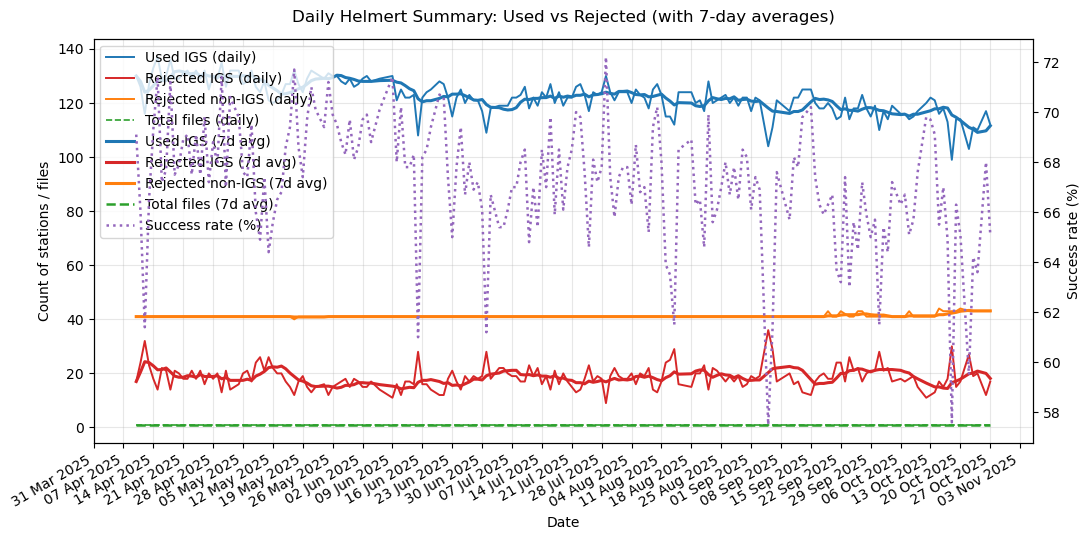

Saved NZ usage stacked bar to C:\Users\LHansen\OneDrive - Land Information New Zealand\2025\Python\Scripts\IGG_sites_check\plots\nz_usage_stacked.png


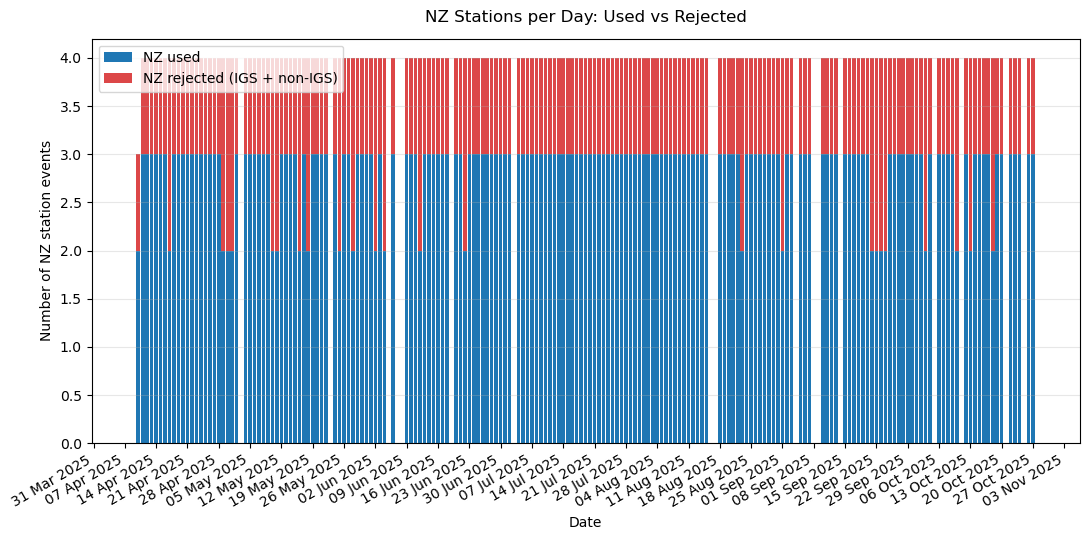

Saved top sites plot to C:\Users\LHansen\OneDrive - Land Information New Zealand\2025\Python\Scripts\IGG_sites_check\plots\top_sites_used_days.png


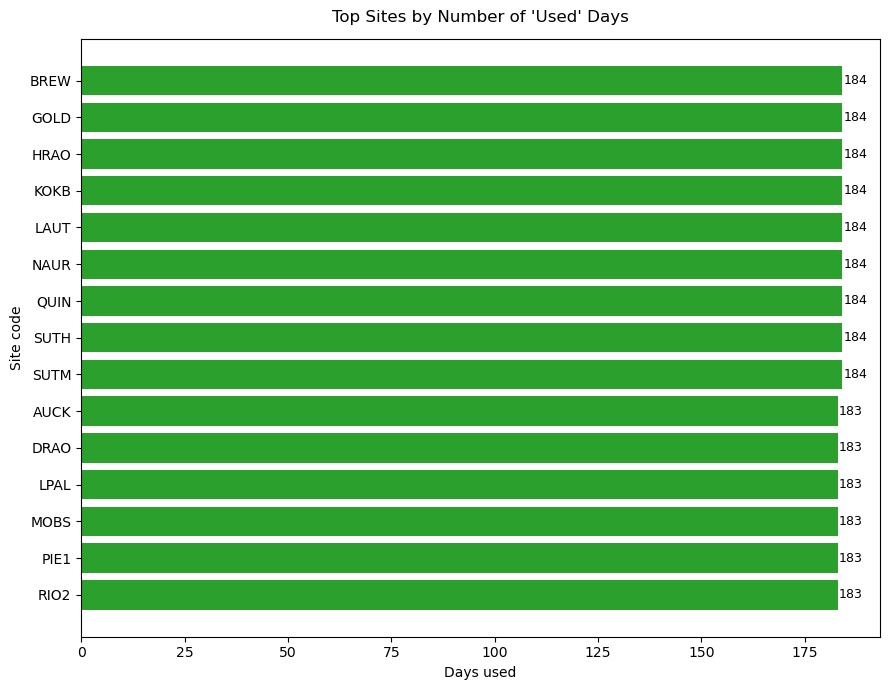

Saved outlier days plot to C:\Users\LHansen\OneDrive - Land Information New Zealand\2025\Python\Scripts\IGG_sites_check\plots\outlier_days.png


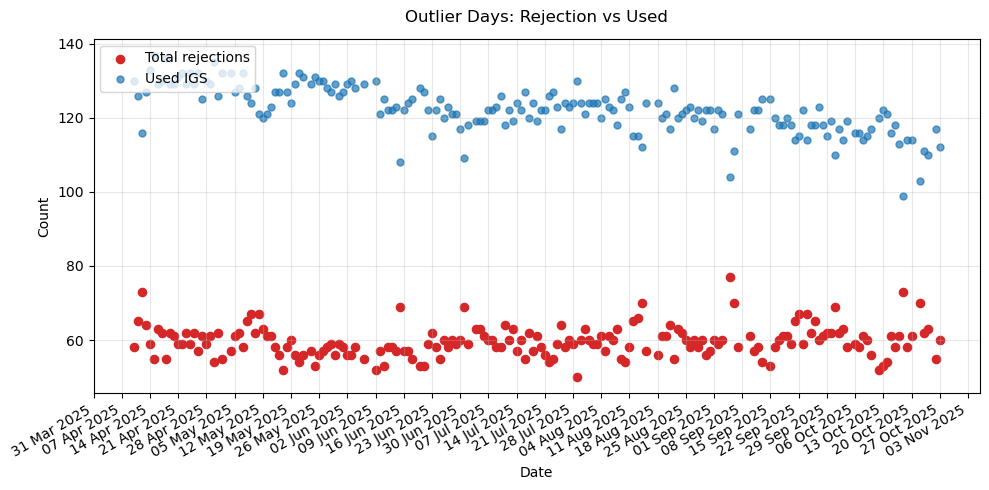

In [82]:
PLOT_DIR = Path(".") / "plots"
PLOT_DIR.mkdir(exist_ok=True)

# -----------------------------
# Helper: date axis formatting
# -----------------------------
def format_date_axis(ax):
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
    plt.gcf().autofmt_xdate()

# -----------------------------
# 1) Daily trends (lines)
# -----------------------------
if isinstance(daily_summary, pd.DataFrame) and not daily_summary.empty:
    ds = daily_summary.sort_values("date").copy()

    # 7-day rolling averages for smoother trend lines
    for col in ["used_igs", "rej_igs", "rej_nonigs", "files"]:
        ds[f"{col}_roll7"] = ds[col].rolling(window=7, min_periods=1).mean()

    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.plot(ds["date"], ds["used_igs"], label="Used IGS (daily)", color="#1f77b4", linewidth=1.4)
    ax.plot(ds["date"], ds["rej_igs"], label="Rejected IGS (daily)", color="#d62728", linewidth=1.4)
    ax.plot(ds["date"], ds["rej_nonigs"], label="Rejected non-IGS (daily)", color="#ff7f0e", linewidth=1.4)
    ax.plot(ds["date"], ds["files"], label="Total files (daily)", color="#2ca02c", linewidth=1.2, linestyle="--")

    # Rolling averages
    ax.plot(ds["date"], ds["used_igs_roll7"], label="Used IGS (7d avg)", color="#1f77b4", linewidth=2.2)
    ax.plot(ds["date"], ds["rej_igs_roll7"], label="Rejected IGS (7d avg)", color="#d62728", linewidth=2.2)
    ax.plot(ds["date"], ds["rej_nonigs_roll7"], label="Rejected non-IGS (7d avg)", color="#ff7f0e", linewidth=2.2)
    ax.plot(ds["date"], ds["files_roll7"], label="Total files (7d avg)", color="#2ca02c", linewidth=1.8, linestyle="--")

    # Secondary axis for success rate (%), if available
    if "success_rate" in ds.columns and ds["success_rate"].notna().any():
        ax2 = ax.twinx()
        ax2.plot(ds["date"], ds["success_rate"] * 100, label="Success rate (%)", color="#9467bd", linewidth=1.8, linestyle=":")
        ax2.set_ylabel("Success rate (%)")
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
    else:
        ax.legend(loc="upper left")

    format_date_axis(ax)
    ax.set_title("Daily Helmert Summary: Used vs Rejected (with 7-day averages)", pad=12)
    ax.set_xlabel("Date")
    ax.set_ylabel("Count of stations / files")
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    out_path = PLOT_DIR / "daily_trends.png"
    fig.savefig(out_path, dpi=150)
    print("Saved daily trends plot to", out_path.resolve())
    plt.show()
else:
    print("INFO: 'daily_summary' is empty; skipping daily trends plot.")

# ------------------------------------
# 2) NZ usage (stacked bar by status)
# ------------------------------------
if isinstance(nz_usage, pd.DataFrame) and not nz_usage.empty:
    nz = nz_usage.sort_values("date").copy()
    nz["nz_rejected_total"] = nz["nz_rej_igs"].fillna(0) + nz["nz_rej_nonigs"].fillna(0)

    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.bar(nz["date"], nz["nz_used"], label="NZ used", color="#1f77b4")
    ax.bar(nz["date"], nz["nz_rejected_total"], bottom=nz["nz_used"],
           label="NZ rejected (IGS + non-IGS)", color="#d62728", alpha=0.85)

    format_date_axis(ax)
    ax.set_title("NZ Stations per Day: Used vs Rejected", pad=12)
    ax.set_xlabel("Date")
    ax.set_ylabel("Number of NZ station events")
    ax.legend(loc="upper left")
    ax.grid(True, axis="y", alpha=0.3)

    fig.tight_layout()
    out_path = PLOT_DIR / "nz_usage_stacked.png"
    fig.savefig(out_path, dpi=150)
    print("Saved NZ usage stacked bar to", out_path.resolve())
    plt.show()
else:
    print("INFO: 'nz_usage' is empty; skipping NZ usage plot.")

# -------------------------------------------------
# 3) Top sites by 'used' days (horizontal bars)
# -------------------------------------------------
if "site_summary" in globals() and isinstance(site_summary, pd.DataFrame) and not site_summary.empty:
    top_n = 15
    top_used = site_summary.sort_values(["used_days", "days"], ascending=[False, False]).head(top_n)

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(top_used["site"], top_used["used_days"], color="#2ca02c")
    ax.invert_yaxis()

    ax.set_title("Top Sites by Number of 'Used' Days", pad=12)
    ax.set_xlabel("Days used")
    ax.set_ylabel("Site code")

    # Value labels
    for i, v in enumerate(top_used["used_days"]):
        ax.text(float(v) + 0.3, i, f"{int(v)}", va="center", fontsize=9)

    fig.tight_layout()
    out_path = PLOT_DIR / "top_sites_used_days.png"
    fig.savefig(out_path, dpi=150)
    print("Saved top sites plot to", out_path.resolve())
    plt.show()
else:
    print("INFO: 'site_summary' missing or empty; skipping top sites plot.")

# -------------------------------------------------
# 4) Outlier days (rejection-heavy scatter)
# -------------------------------------------------
if isinstance(daily_summary, pd.DataFrame) and not daily_summary.empty:
    ds = daily_summary.sort_values("date").copy()
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(ds["date"], ds["rej_total"], s=35, color="#d62728", label="Total rejections")
    ax.scatter(ds["date"], ds["used_igs"], s=25, color="#1f77b4", alpha=0.7, label="Used IGS")

    format_date_axis(ax)
    ax.set_title("Outlier Days: Rejection vs Used", pad=12)
    ax.set_xlabel("Date")
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")

    fig.tight_layout()  # <-- fixed indentation here
    out_path = PLOT_DIR / "outlier_days.png"
    fig.savefig(out_path, dpi=150)
    print("Saved outlier days plot to", out_path.resolve())
    plt.show()
else:
    print("INFO: 'daily_summary' is empty; skipping outlier days plot.")


Saved Top NZ sites plot to C:\Users\LHansen\OneDrive - Land Information New Zealand\2025\Python\Scripts\IGG_sites_check\plots\top_nz_sites_used_days.png


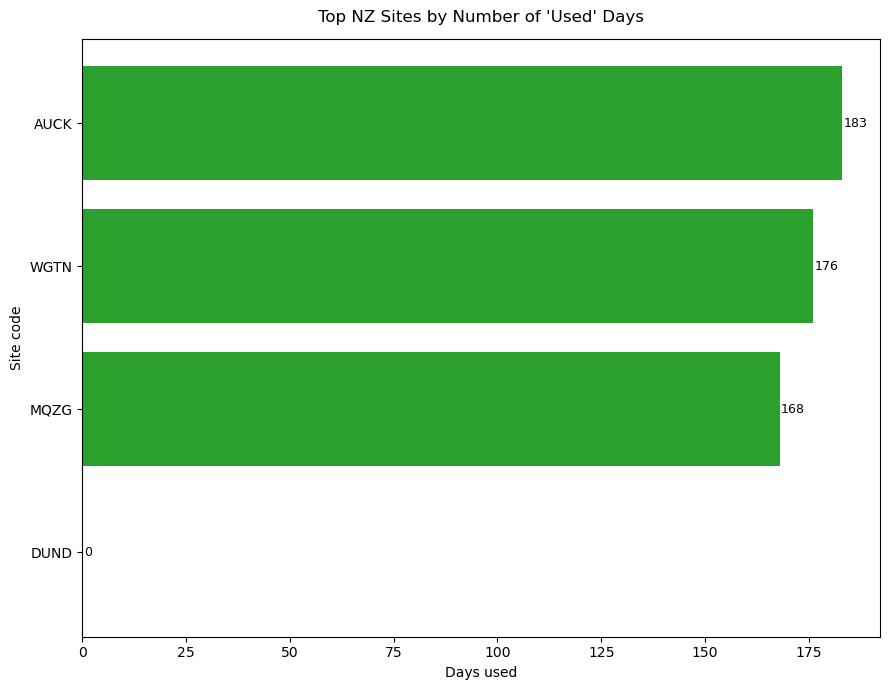

In [83]:
PLOT_DIR = Path(".") / "plots"
PLOT_DIR.mkdir(exist_ok=True)

def plot_top_nz_sites(site_summary: pd.DataFrame, nz_codes, top_n: int = 15):
    if not isinstance(site_summary, pd.DataFrame) or site_summary.empty:
        print("INFO: 'site_summary' missing or empty; cannot plot NZ sites.")
        return

    if not nz_codes:
        print("INFO: 'NZ_CODES' is empty or undefined; cannot filter to NZ sites.")
        return

    nz_set = {str(s).upper() for s in nz_codes}
    # Normalise site codes in the DataFrame as well
    nz_sites = site_summary.copy()
    nz_sites["site_norm"] = nz_sites["site"].str.upper()

    nz_sites = nz_sites[nz_sites["site_norm"].isin(nz_set)]
    if nz_sites.empty:
        print("INFO: No NZ stations found in 'site_summary' using the provided NZ_CODES.")
        return

    # Order by used_days then total days (tie-breaker)
    top = nz_sites.sort_values(["used_days", "days"], ascending=[False, False]).head(top_n)

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(top["site"], top["used_days"], color="#2ca02c")
    ax.invert_yaxis()

    ax.set_title("Top NZ Sites by Number of 'Used' Days", pad=12)
    ax.set_xlabel("Days used")
    ax.set_ylabel("Site code")

    # Value labels on bars
    for i, v in enumerate(top["used_days"]):
        ax.text(float(v) + 0.3, i, f"{int(v)}", va="center", fontsize=9)

    fig.tight_layout()
    out_path = PLOT_DIR / "top_nz_sites_used_days.png"
    fig.savefig(out_path, dpi=150)
    print("Saved Top NZ sites plot to", out_path.resolve())
    plt.show()

# Call it:
plot_top_nz_sites(site_summary, NZ_CODES, top_n=15)


Saved daily 3D RMS plot to C:\Users\LHansen\OneDrive - Land Information New Zealand\2025\Python\Scripts\IGG_sites_check\plots\daily_rms_3d_mm.png


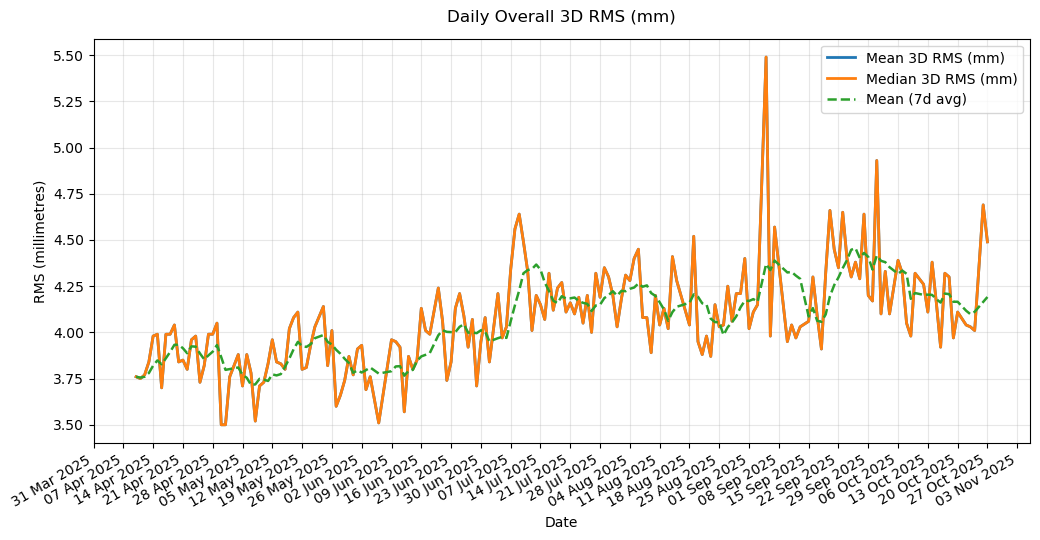

Saved per-file RMS scatter to C:\Users\LHansen\OneDrive - Land Information New Zealand\2025\Python\Scripts\IGG_sites_check\plots\scatter_rms_3d_mm.png


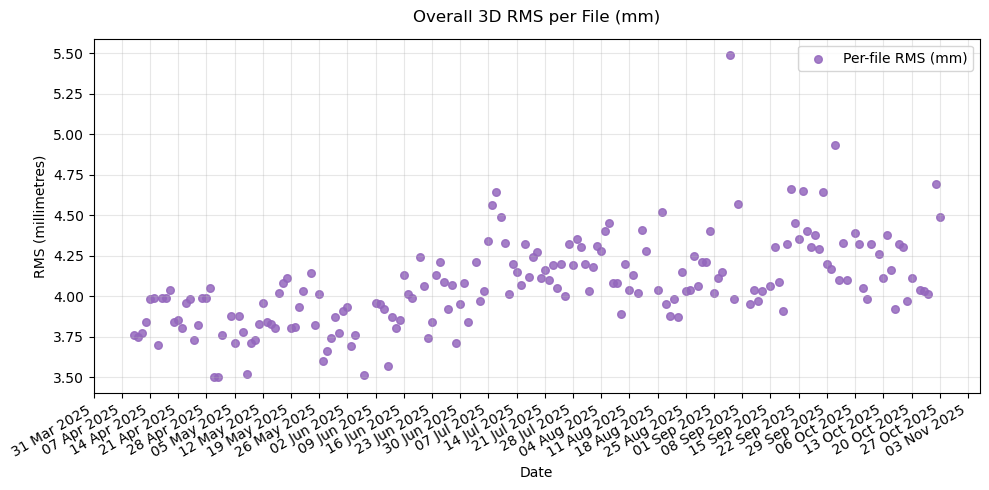

Saved histogram of 3D RMS to C:\Users\LHansen\OneDrive - Land Information New Zealand\2025\Python\Scripts\IGG_sites_check\plots\hist_rms_3d_mm.png


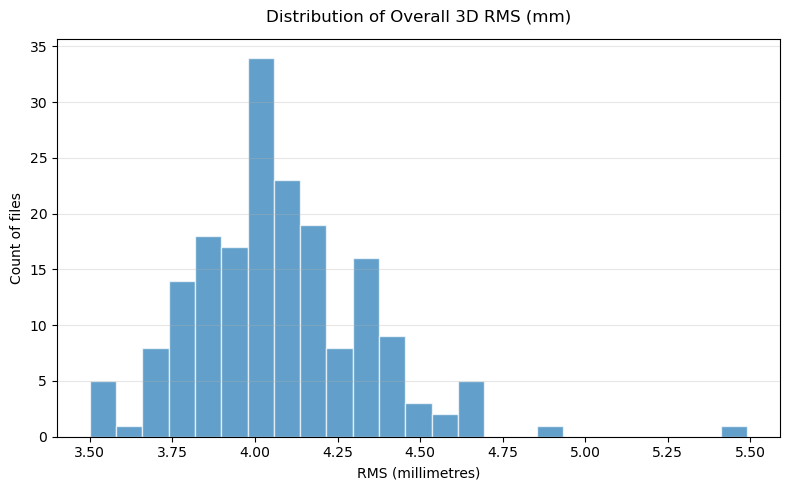

In [85]:
# Where to save figures
PLOT_DIR = Path(".") / "plots"
PLOT_DIR.mkdir(exist_ok=True)

# ---------- RMS extractor ----------
def extract_overall_rms_3d(text: str):
    """
    Parse Helmert output text and return overall 3D RMS as a float in millimetres,
    or None if not found. Converts cm->mm and m->mm when unit provided.
    Ignores ppm (returns None to avoid unit mixing).
    """
    patterns = [
        r"OVERALL\s+RMS(?:/IQR/MAX)?\s*\(\s*3D\s*\)\s*[:=]\s*([0-9]*\.?[0-9]+)\s*(mm|cm|m|ppm)?",
        r"OVERALL\s+RMS\s*3D\s*[:=]\s*([0-9]*\.?[0-9]+)\s*(mm|cm|m|ppm)?",
        r"RMS\s+OF\s+TRANSFORMATION\s*[:=]\s*([0-9]*\.?[0-9]+)\s*(mm|cm|m|ppm)?",
    ]
    for rx in patterns:
        m = re.search(rx, text, flags=re.IGNORECASE)
        if m:
            val = m.group(1)
            unit = (m.group(2) or "").lower().strip()
            try:
                x = float(val)
            except Exception:
                continue
            if unit in ("", "mm"):
                return x
            if unit == "cm":
                return x * 10.0
            if unit == "m":
                return x * 1000.0
            if unit == "ppm":
                return None  # avoid mixing ppm with mm
            return x
    return None

# ---------- Enrich df with RMS ----------
def ensure_rms_3d_in_df(df: pd.DataFrame):
    """
    Ensure df has a 'rms_3d_mm' column by reading files from FILES using read_text_safe,
    mapping by file name. If the column exists and has values, it is left as-is.
    """
    if not isinstance(df, pd.DataFrame) or df.empty:
        print("INFO: 'df' missing or empty; cannot enrich RMS.")
        return df

    needs_rms = ("rms_3d_mm" not in df.columns) or df["rms_3d_mm"].isna().all()
    if not needs_rms:
        return df

    if "FILES" not in globals() or not FILES or "read_text_safe" not in globals():
        print("INFO: 'FILES' or 'read_text_safe' not available; cannot enrich RMS.")
        return df

    # Build a quick lookup: file name -> Path
    path_by_name = {p.name: p for p in FILES}
    rms_vals = {}
    for fname in df["file"].dropna().unique():
        p = path_by_name.get(str(fname))
        if p:
            try:
                text = read_text_safe(p)
            except Exception:
                text = ""
            rms_vals[fname] = extract_overall_rms_3d(text)
        else:
            rms_vals[fname] = None

    df = df.copy()
    df["rms_3d_mm"] = df["file"].map(rms_vals)
    return df

# ---------- Helper: format date axis ----------
def _format_date_axis(ax):
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
    plt.gcf().autofmt_xdate()

# ---------- Build daily RMS summary ----------
def build_daily_rms(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create a per-day summary of mean and median 3D RMS (mm).
    """
    if not isinstance(df, pd.DataFrame) or df.empty or "rms_3d_mm" not in df.columns:
        return pd.DataFrame(columns=["date", "rms_mean_mm", "rms_median_mm", "samples"])

    dfr = df.copy()
    dfr["date"] = pd.to_datetime(dfr["date"], errors="coerce").dt.floor("D")
    dfr = dfr[dfr["rms_3d_mm"].notna()]
    if dfr.empty:
        return pd.DataFrame(columns=["date", "rms_mean_mm", "rms_median_mm", "samples"])

    daily = (
        dfr.dropna(subset=["date"])
           .groupby("date")
           .agg(
               rms_mean_mm=("rms_3d_mm", "mean"),
               rms_median_mm=("rms_3d_mm", "median"),
               samples=("rms_3d_mm", "count"),
           )
           .reset_index()
           .sort_values("date")
    )
    return daily

# ---------- Plots ----------
def plot_daily_rms(daily_rms: pd.DataFrame, out_dir: Path = PLOT_DIR):
    """
    Plot daily mean and median RMS (with a 7-day rolling average of the mean).
    """
    if not isinstance(daily_rms, pd.DataFrame) or daily_rms.empty:
        print("INFO: 'daily_rms' empty; skipping daily RMS plot.")
        return
    ds = daily_rms.copy()
    ds["mean_roll7"] = ds["rms_mean_mm"].rolling(window=7, min_periods=1).mean()

    fig, ax = plt.subplots(figsize=(10.5, 5.5))
    ax.plot(ds["date"], ds["rms_mean_mm"], label="Mean 3D RMS (mm)", color="#1f77b4", linewidth=2.0)
    ax.plot(ds["date"], ds["rms_median_mm"], label="Median 3D RMS (mm)", color="#ff7f0e", linewidth=2.0)
    ax.plot(ds["date"], ds["mean_roll7"], label="Mean (7d avg)", color="#2ca02c", linewidth=1.8, linestyle="--")

    _format_date_axis(ax)
    ax.set_title("Daily Overall 3D RMS (mm)", pad=12)
    ax.set_xlabel("Date")
    ax.set_ylabel("RMS (millimetres)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")

    fig.tight_layout()
    out_path = out_dir / "daily_rms_3d_mm.png"
    fig.savefig(out_path, dpi=150)
    print("Saved daily 3D RMS plot to", out_path.resolve())
    plt.show()

def plot_scatter_rms(df: pd.DataFrame, out_dir: Path = PLOT_DIR):
    """
    Scatter plot of per-file overall 3D RMS (mm).
    """
    if not isinstance(df, pd.DataFrame) or df.empty or "rms_3d_mm" not in df.columns:
        print("INFO: 'df' missing or no 'rms_3d_mm'; skipping scatter RMS plot.")
        return

    dfr = df.copy()
    dfr["date"] = pd.to_datetime(dfr["date"], errors="coerce").dt.floor("D")
    dfr = dfr[dfr["rms_3d_mm"].notna()]
    if dfr.empty:
        print("INFO: No RMS values to plot in scatter.")
        return

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(dfr["date"], dfr["rms_3d_mm"], s=30, color="#9467bd", alpha=0.85, label="Per-file RMS (mm)")
    _format_date_axis(ax)
    ax.set_title("Overall 3D RMS per File (mm)", pad=12)
    ax.set_xlabel("Date")
    ax.set_ylabel("RMS (millimetres)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")

    fig.tight_layout()
    out_path = out_dir / "scatter_rms_3d_mm.png"
    fig.savefig(out_path, dpi=150)
    print("Saved per-file RMS scatter to", out_path.resolve())
    plt.show()

def plot_hist_rms(df: pd.DataFrame, out_dir: Path = PLOT_DIR):
    """
    Histogram of overall 3D RMS (mm) across files.
    """
    if not isinstance(df, pd.DataFrame) or df.empty or "rms_3d_mm" not in df.columns:
        print("INFO: 'df' missing or no 'rms_3d_mm'; skipping RMS histogram.")
        return

    dfr = df[df["rms_3d_mm"].notna()]
    if dfr.empty:
        print("INFO: No RMS values to plot in histogram.")
        return

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(dfr["rms_3d_mm"], bins=25, color="#1f77b4", alpha=0.7, edgecolor="white")
    ax.set_title("Distribution of Overall 3D RMS (mm)", pad=12)
    ax.set_xlabel("RMS (millimetres)")
    ax.set_ylabel("Count of files")
    ax.grid(True, axis="y", alpha=0.3)

    fig.tight_layout()
    out_path = out_dir / "hist_rms_3d_mm.png"
    fig.savefig(out_path, dpi=150)
    print("Saved histogram of 3D RMS to", out_path.resolve())
    plt.show()

# ---------- Driver ----------
# Enrich df with RMS (only if needed), then build daily summary and plot
df = ensure_rms_3d_in_df(df)
daily_rms = build_daily_rms(df)
plot_daily_rms(daily_rms, out_dir=PLOT_DIR)
plot_scatter_rms(df, out_dir=PLOT_DIR)
plot_hist_rms(df, out_dir=PLOT_DIR)



NZ per-site summary (top 10):
   site  days  used_days  rej_days  used_ratio
0  AUCK   184        183         1       0.995
3  WGTN   183        176         7       0.962
2  MQZG   184        168        16       0.913
1  DUND   184          0       184       0.000
Saved NZ RMS scatter plot to C:\Users\LHansen\OneDrive - Land Information New Zealand\2025\Python\Scripts\IGG_sites_check\plots\nz_scatter_rms_3d_mm.png


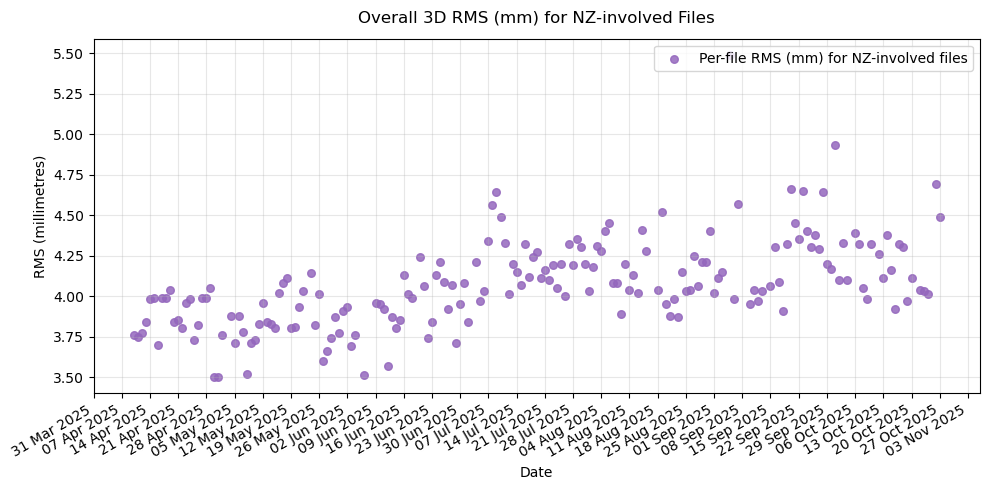

In [90]:

# Step 10 — NZ-only checks (without the first two plots)
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

PLOT_DIR = Path(".") / "plots"
PLOT_DIR.mkdir(exist_ok=True)

def _format_date_axis(ax):
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
    plt.gcf().autofmt_xdate()

def _is_nz_site(code, nz_set):
    return isinstance(code, str) and code.upper() in nz_set

def nz_events_from_df(df: pd.DataFrame, nz_codes) -> pd.DataFrame:
    if not isinstance(df, pd.DataFrame) or df.empty or not nz_codes:
        return pd.DataFrame(columns=["site", "date", "status"])

    nz_set = {str(s).upper() for s in nz_codes}
    rows = []
    for _, row in df.iterrows():
        dt = pd.to_datetime(row.get("date"), errors="coerce")
        for s in (row.get("used_igs_sites") or []):
            if _is_nz_site(s, nz_set):
                rows.append({"site": s.upper(), "date": dt, "status": "USED"})
        for s in (row.get("rejected_igs_sites") or []):
            if _is_nz_site(s, nz_set):
                rows.append({"site": s.upper(), "date": dt, "status": "REJ_IGS"})
        for s in (row.get("rejected_nonigs_sites") or []):
            if _is_nz_site(s, nz_set):
                rows.append({"site": s.upper(), "date": dt, "status": "REJ_NONIGS"})
    ev = pd.DataFrame(rows)
    if not ev.empty:
        ev = ev[ev["date"].notna()]
    return ev

def nz_daily_summary(ev: pd.DataFrame) -> pd.DataFrame:
    if not isinstance(ev, pd.DataFrame) or ev.empty:
        return pd.DataFrame(columns=["date","nz_used","nz_rej_igs","nz_rej_nonigs","nz_rej_total","nz_sites_covered"])

    grp = (
        ev.groupby(["date", "status"])
          .size()
          .unstack(fill_value=0)
          .rename(columns={"USED":"nz_used","REJ_IGS":"nz_rej_igs","REJ_NONIGS":"nz_rej_nonigs"})
          .reset_index()
    )
    for col in ["nz_used","nz_rej_igs","nz_rej_nonigs"]:
        if col not in grp.columns:
            grp[col] = 0
    grp["nz_rej_total"] = grp["nz_rej_igs"] + grp["nz_rej_nonigs"]

    sites_per_day = ev.groupby("date")["site"].nunique().rename("nz_sites_covered").reset_index()
    daily = grp.merge(sites_per_day, on="date", how="left").sort_values("date")
    return daily

def nz_site_summary(ev: pd.DataFrame) -> pd.DataFrame:
    if not isinstance(ev, pd.DataFrame) or ev.empty:
        return pd.DataFrame(columns=["site","days","used_days","rej_days","used_ratio"])

    day_flags = (
        ev.assign(day=lambda d: d["date"].dt.floor("D"))
          .groupby(["site","day"])
          .agg(
              any_used=("status", lambda s: (s == "USED").any()),
              any_rej=("status", lambda s: s.str.startswith("REJ").any()),
          )
          .reset_index()
    )
    site_sum = (
        day_flags.groupby("site")
                 .agg(
                     days=("day", "nunique"),
                     used_days=("any_used", "sum"),
                     rej_days=("any_rej", "sum"),
                 )
                 .reset_index()
    )
    site_sum["used_ratio"] = (site_sum["used_days"] / site_sum["days"]).round(3)
    return site_sum

# ---- Only keep the NZ RMS scatter plot ----
def plot_nz_rms(df: pd.DataFrame, nz_codes, out_dir: Path = PLOT_DIR):
    if not isinstance(df, pd.DataFrame) or df.empty or "rms_3d_mm" not in df.columns:
        print("INFO: 'df' missing or 'rms_3d_mm' not present; skipping NZ RMS plot.")
        return
    nz_set = {str(s).upper() for s in nz_codes} if nz_codes else set()
    if not nz_set:
        print("INFO: NZ_CODES empty; skipping NZ RMS plot.")
        return

    def has_nz(row):
        for col in ("used_igs_sites","rejected_igs_sites","rejected_nonigs_sites"):
            for s in (row.get(col) or []):
                if _is_nz_site(s, nz_set):
                    return True
        return False

    dfr = df.copy()
    dfr["date"] = pd.to_datetime(dfr["date"], errors="coerce").dt.floor("D")
    dfr = dfr[dfr.apply(has_nz, axis=1)]
    dfr = dfr[dfr["rms_3d_mm"].notna()]
    if dfr.empty:
        print("INFO: No NZ-matched files with RMS values; skipping NZ RMS plot.")
        return

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(dfr["date"], dfr["rms_3d_mm"], s=30, color="#9467bd", alpha=0.85, label="Per-file RMS (mm) for NZ-involved files")
    _format_date_axis(ax)
    ax.set_title("Overall 3D RMS (mm) for NZ-involved Files", pad=12)
    ax.set_xlabel("Date")
    ax.set_ylabel("RMS (millimetres)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")

    fig.tight_layout()
    out_path = out_dir / "nz_scatter_rms_3d_mm.png"
    fig.savefig(out_path, dpi=150)
    print("Saved NZ RMS scatter plot to", out_path.resolve())
    plt.show()

# ---- Execute (no daily/Top NZ plots) ----
nz_ev = nz_events_from_df(df, NZ_CODES)
nz_daily = nz_daily_summary(nz_ev)      # still computed, in case you need the table
nz_sites_sum = nz_site_summary(nz_ev)   # still computed, in case you need the table



print("\nNZ per-site summary (top 10):")
print(
    nz_sites_sum
        .sort_values(['used_ratio', 'days'], ascending=[False, False])
        .head(10)
)

# Only plot NZ RMS scatter:
plot_nz_rms(df, NZ_CODES, out_dir=PLOT_DIR)



Saved NZ histogram of 3D RMS to C:\Users\LHansen\OneDrive - Land Information New Zealand\2025\Python\Scripts\IGG_sites_check\plots\nz_hist_rms_3d_mm.png


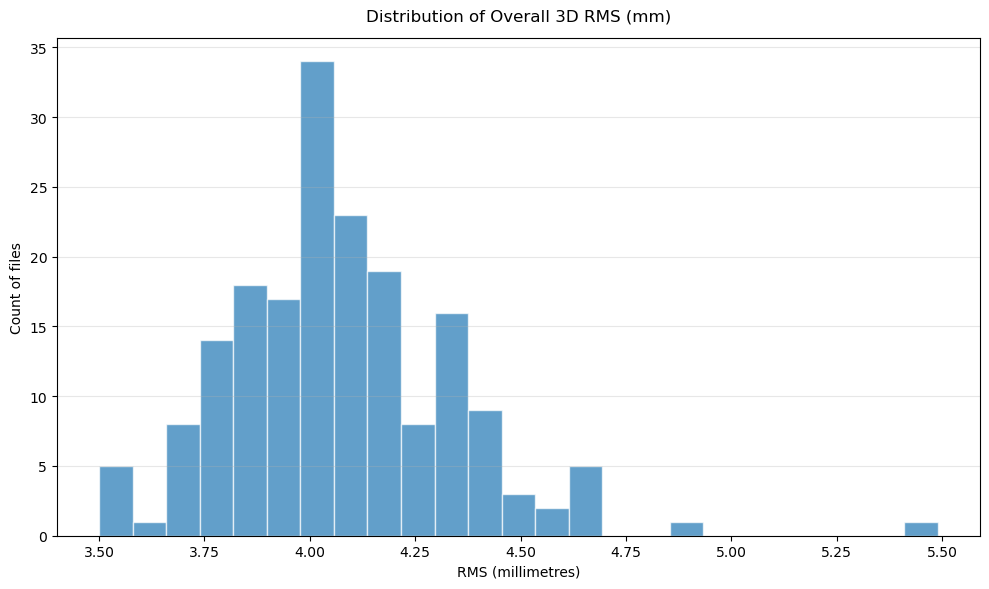

Saved NZ daily 3D RMS plot to C:\Users\LHansen\OneDrive - Land Information New Zealand\2025\Python\Scripts\IGG_sites_check\plots\nz_daily_rms_3d_mm.png


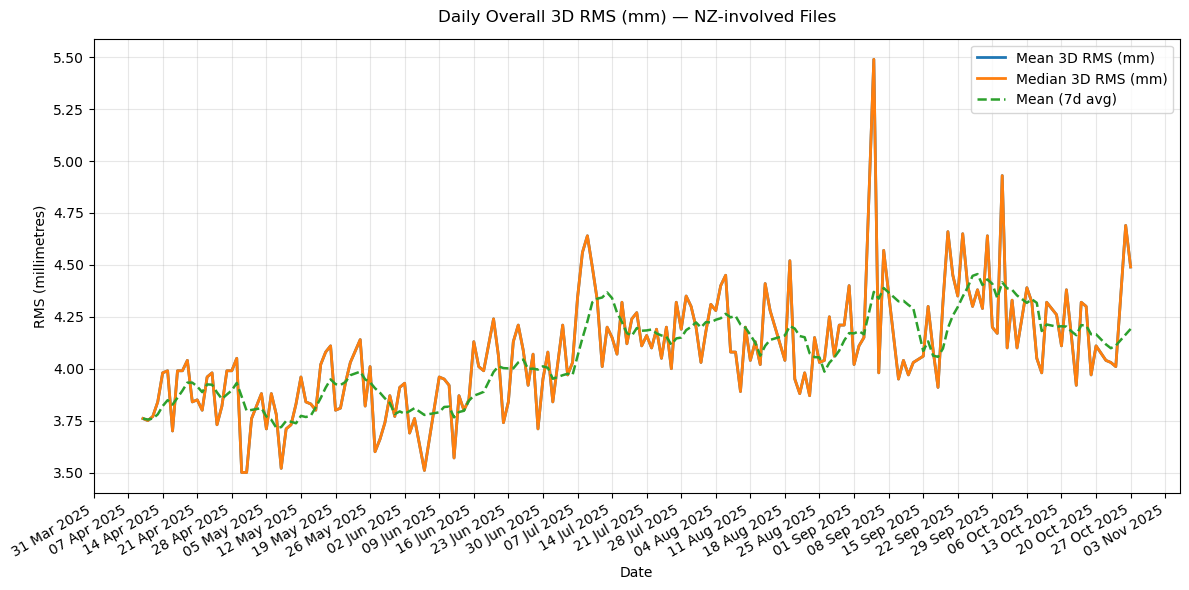

In [93]:
PLOT_DIR = Path(".") / "plots"
PLOT_DIR.mkdir(exist_ok=True)

# Helper (include if not already defined)
def _format_date_axis(ax):
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
    plt.gcf().autofmt_xdate()

def _is_nz_site(code, nz_set):
    return isinstance(code, str) and code.upper() in nz_set

def _df_nz_involved(df: pd.DataFrame, nz_codes) -> pd.DataFrame:
    """
    Return a subset of df containing only rows (files) that involve at least one NZ site
    in any of the site lists (used/rejected). Requires df['rms_3d_mm'].
    """
    if not isinstance(df, pd.DataFrame) or df.empty or "rms_3d_mm" not in df.columns:
        return pd.DataFrame(columns=df.columns)
    nz_set = {str(s).upper() for s in nz_codes} if nz_codes else set()
    if not nz_set:
        return pd.DataFrame(columns=df.columns)

    def has_nz(row):
        for col in ("used_igs_sites", "rejected_igs_sites", "rejected_nonigs_sites"):
            for s in (row.get(col) or []):
                if _is_nz_site(s, nz_set):
                    return True
        return False

    dfr = df.copy()
    dfr["date"] = pd.to_datetime(dfr["date"], errors="coerce").dt.floor("D")
    dfr = dfr[dfr.apply(has_nz, axis=1)]
    dfr = dfr[dfr["rms_3d_mm"].notna()]
    return dfr

# -------- 1) NZ-only RMS histogram --------
def plot_nz_rms_histogram(df: pd.DataFrame, nz_codes, out_dir: Path = PLOT_DIR, bins: int = 25):
    nz_df = _df_nz_involved(df, nz_codes)
    if nz_df.empty:
        print("INFO: No NZ-involved files with RMS values; skipping NZ RMS histogram.")
        return

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(nz_df["rms_3d_mm"], bins=bins, color="#1f77b4", alpha=0.7, edgecolor="white")
    ax.set_title("Distribution of Overall 3D RMS (mm)", pad=12)
    ax.set_xlabel("RMS (millimetres)")
    ax.set_ylabel("Count of files")
    ax.grid(True, axis="y", alpha=0.3)

    fig.tight_layout()
    out_path = out_dir / "nz_hist_rms_3d_mm.png"
    fig.savefig(out_path, dpi=150)
    print("Saved NZ histogram of 3D RMS to", out_path.resolve())
    plt.show()

# -------- 2) NZ-only daily RMS lines --------
def plot_nz_daily_rms(df: pd.DataFrame, nz_codes, out_dir: Path = PLOT_DIR):
    nz_df = _df_nz_involved(df, nz_codes)
    if nz_df.empty:
        print("INFO: No NZ-involved files with RMS values; skipping NZ daily RMS plot.")
        return

    daily = (
        nz_df.dropna(subset=["date"])
             .groupby("date")
             .agg(
                 rms_mean_mm=("rms_3d_mm", "mean"),
                 rms_median_mm=("rms_3d_mm", "median"),
                 samples=("rms_3d_mm", "count"),
             )
             .reset_index()
             .sort_values("date")
    )
    if daily.empty:
        print("INFO: NZ daily RMS summary empty; skipping plot.")
        return

    daily["mean_roll7"] = daily["rms_mean_mm"].rolling(window=7, min_periods=1).mean()

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(daily["date"], daily["rms_mean_mm"], label="Mean 3D RMS (mm)", color="#1f77b4", linewidth=2.0)
    ax.plot(daily["date"], daily["rms_median_mm"], label="Median 3D RMS (mm)", color="#ff7f0e", linewidth=2.0)
    ax.plot(daily["date"], daily["mean_roll7"], label="Mean (7d avg)", color="#2ca02c", linewidth=1.8, linestyle="--")

    _format_date_axis(ax)
    ax.set_title("Daily Overall 3D RMS (mm) — NZ-involved Files", pad=12)
    ax.set_xlabel("Date")
    ax.set_ylabel("RMS (millimetres)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")

    fig.tight_layout()
    out_path = out_dir / "nz_daily_rms_3d_mm.png"
    fig.savefig(out_path, dpi=150)
    print("Saved NZ daily 3D RMS plot to", out_path.resolve())
    plt.show()



# -------- Execute the two NZ RMS plots --------
plot_nz_rms_histogram(df, NZ_CODES, out_dir=PLOT_DIR, bins=25)
plot_nz_daily_rms(df, NZ_CODES, out_dir=PLOT_DIR)


NZ residual events (first 10 rows):
               file       date  site status tail    r1    r2    r3   r_mag_mm
0  HLM_20251000.OUT 2025-04-10  AUCK     IW      -2.02  0.86  0.22   2.206445
1  HLM_20251000.OUT 2025-04-10  DUND     UA    V  0.26 -0.11 -0.26   0.383797
2  HLM_20251000.OUT 2025-04-10  MQZG     IW      -0.45  1.78 -1.12   2.150651
3  HLM_20251010.OUT 2025-04-11  AUCK     IW      -3.33 -0.60  0.13   3.386119
4  HLM_20251010.OUT 2025-04-11  DUND     UA    V  2.71  1.35  0.23   3.036363
5  HLM_20251010.OUT 2025-04-11  MQZG     IW       7.59  6.95  0.96  10.335966
6  HLM_20251010.OUT 2025-04-11  WGTN     IW       0.70 -2.33  3.80   4.512084
7  HLM_20251020.OUT 2025-04-12  AUCK     IW       0.50  2.01 -0.87   2.246553
8  HLM_20251020.OUT 2025-04-12  DUND     UA    V  3.17  1.21 -1.59   3.747146
9  HLM_20251020.OUT 2025-04-12  MQZG     IW       3.45  2.92 -2.33   5.085057

NZ residual RMS daily (head):
        date  nz_rms_mean_mm  nz_rms_median_mm  nz_rows  nz_rms_mean_roll7

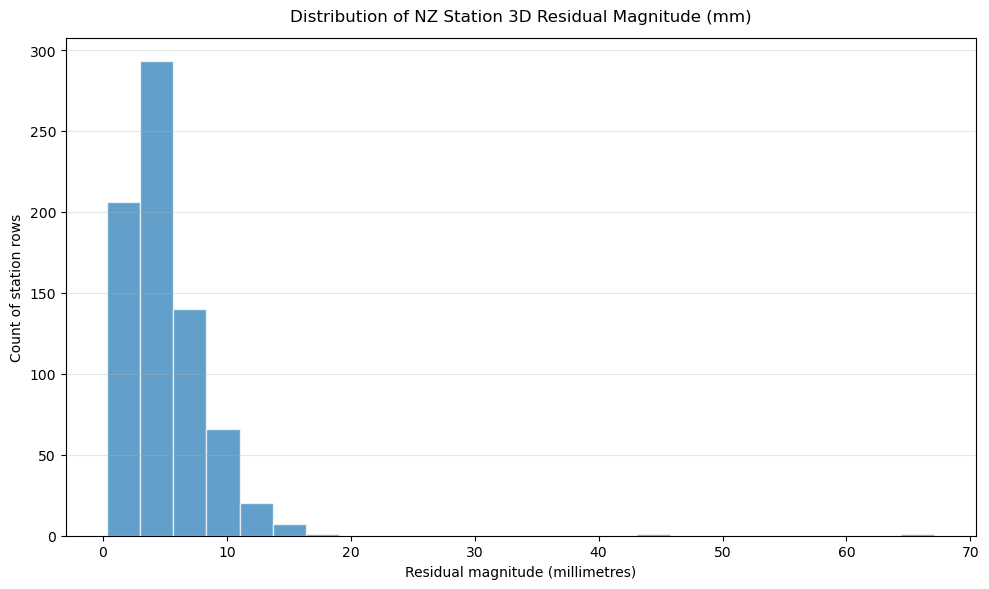

Saved NZ daily residual RMS plot to C:\Users\LHansen\OneDrive - Land Information New Zealand\2025\Python\Scripts\IGG_sites_check\plots\nz_residual_rms_daily.png


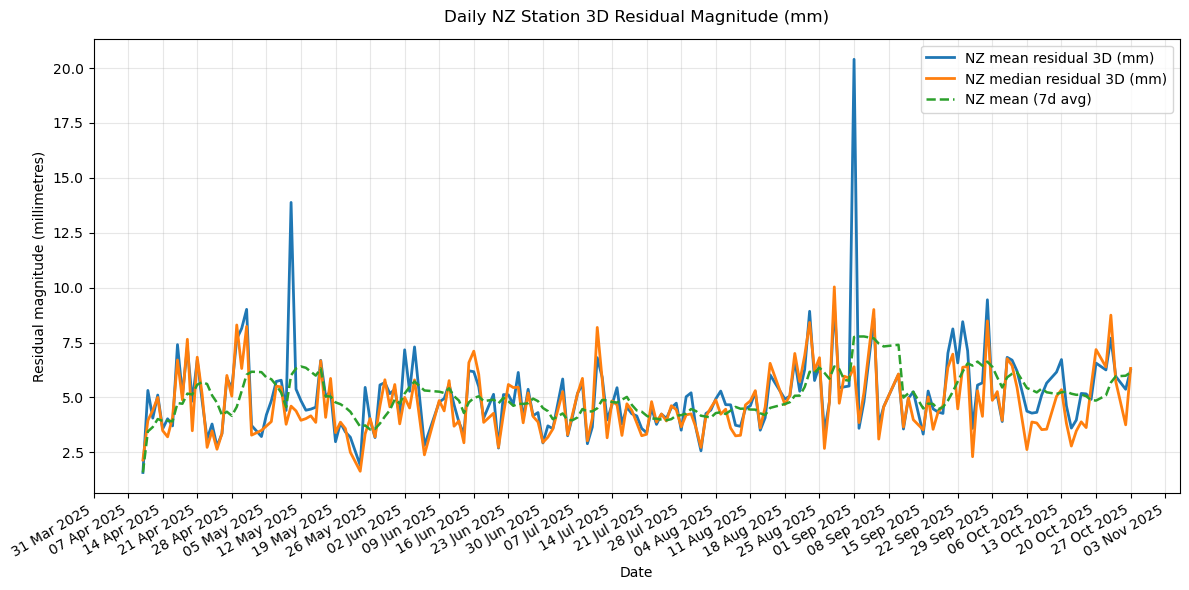

In [96]:

# Step X — Compute NZ-only RMS directly from station residuals
import re
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

PLOT_DIR = Path(".") / "plots"
PLOT_DIR.mkdir(exist_ok=True)

# --- Helper: date axis formatting ---
def _format_date_axis(ax):
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
    plt.gcf().autofmt_xdate()

# --- Regex to parse pipe-delimited station rows with residuals in mm ---
# Typical line (pipes may vary; header shows "RESIDUALS IN MILLIMETERS"):
# |  10 | AUCK 50209M001 | I W | -2.02  0.86  0.22 | V
ROW_WITH_RESIDUALS_RE = re.compile(
    r"""
    ^\s*\|\s*(\d+)\s*\|                    # row index (unused)
    \s*([A-Za-z0-9]{3,8})\b[^|]*\|         # station code (e.g., AUCK)
    \s*(I\s*[WA]|U\s*A)\s*\|\s*            # status ('I W','I A','U A')
    ([+-]?\d+(?:\.\d+)?)\s+                # residual 1 (mm)
    ([+-]?\d+(?:\.\d+)?)\s+                # residual 2 (mm)
    ([+-]?\d+(?:\.\d+)?)\s*                # residual 3 (mm)
    \|\s*([VR]?)\s*\|?\s*$                 # optional tail flag ('V' or 'R')
    """,
    re.IGNORECASE | re.VERBOSE,
)

# Fallback (less strict; handles lines without pipes but with 3 numbers):
FALLBACK_RESIDUALS_RE = re.compile(
    r"""
    ^\s*(\d+)\s+                           # row index
    ([A-Za-z0-9]{3,8})\b.*?                # station code
    (I\s*[WA]|U\s*A)\b.*?                  # status
    ([+-]?\d+(?:\.\d+)?)\s+                # residual 1 (mm)
    ([+-]?\d+(?:\.\d+)?)\s+                # residual 2 (mm)
    ([+-]?\d+(?:\.\d+)?)\s+                # residual 3 (mm)
    ([VR])?\s*$                            # optional tail
    """,
    re.IGNORECASE | re.VERBOSE,
)

def parse_rows_with_residuals(text: str):
    """
    Yield dicts: {'code','status','tail','r1','r2','r3'} residuals in mm (floats).
    """
    for ln in text.splitlines():
        m = ROW_WITH_RESIDUALS_RE.match(ln) or FALLBACK_RESIDUALS_RE.match(ln)
        if not m:
            continue
        code = m.group(2).strip().upper()
        status = m.group(3).replace(" ", "").upper()  # 'I W' -> 'IW'
        r1 = float(m.group(4))
        r2 = float(m.group(5))
        r3 = float(m.group(6))
        tail = (m.group(7) or "").upper()
        yield {"code": code, "status": status, "tail": tail, "r1": r1, "r2": r2, "r3": r3}

def build_nz_residual_events(files, nz_codes):
    """
    Return a DataFrame of NZ residual events:
      columns: ['file','date','site','status','tail','r1','r2','r3','r_mag_mm']
    where r_mag_mm = sqrt(r1^2 + r2^2 + r3^2).
    """
    nz_set = {str(s).upper() for s in (nz_codes or [])}
    rows = []

    for p in files:
        # You already have read_text_safe and extract_date in earlier steps
        text = read_text_safe(p)
        dt = extract_date(text, p.name)
        date = pd.to_datetime(dt).floor("D") if dt else pd.NaT

        for row in parse_rows_with_residuals(text):
            code = row["code"]
            if code.upper() not in nz_set:
                continue  # NZ-only
            r_mag = math.sqrt(row["r1"]**2 + row["r2"]**2 + row["r3"]**2)
            rows.append({
                "file": p.name,
                "date": date,
                "site": code,
                "status": row["status"],
                "tail": row["tail"],
                "r1": row["r1"],
                "r2": row["r2"],
                "r3": row["r3"],
                "r_mag_mm": r_mag,
            })

    ev = pd.DataFrame(rows)
    # Remove events without a valid date
    if not ev.empty:
        ev = ev[ev["date"].notna()]
    return ev

def nz_daily_rms_from_residuals(ev: pd.DataFrame) -> pd.DataFrame:
    """
    From NZ residual events, compute per-day mean/median of r_mag_mm,
    plus counts of NZ rows contributing that day.
    """
    if not isinstance(ev, pd.DataFrame) or ev.empty:
        return pd.DataFrame(columns=["date","nz_rms_mean_mm","nz_rms_median_mm","nz_rows"])
    daily = (
        ev.groupby("date")
          .agg(
              nz_rms_mean_mm=("r_mag_mm", "mean"),
              nz_rms_median_mm=("r_mag_mm", "median"),
              nz_rows=("r_mag_mm", "count"),
          )
          .reset_index()
          .sort_values("date")
    )
    # Optional: 7-day rolling average for the mean
    daily["nz_rms_mean_roll7"] = daily["nz_rms_mean_mm"].rolling(window=7, min_periods=1).mean()
    return daily

# --- Plots: NZ-only RMS from residuals ---
def plot_nz_residual_rms_hist(ev: pd.DataFrame, out_dir: Path = PLOT_DIR, bins: int = 25):
    if not isinstance(ev, pd.DataFrame) or ev.empty:
        print("INFO: No NZ residual events; skipping histogram.")
        return
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(ev["r_mag_mm"], bins=bins, color="#1f77b4", alpha=0.7, edgecolor="white")
    ax.set_title("Distribution of NZ Station 3D Residual Magnitude (mm)", pad=12)
    ax.set_xlabel("Residual magnitude (millimetres)")
    ax.set_ylabel("Count of station rows")
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    out_path = out_dir / "nz_residual_rms_hist.png"
    fig.savefig(out_path, dpi=150)
    print("Saved NZ residual RMS histogram to", out_path.resolve())
    plt.show()

def plot_nz_residual_rms_daily(daily: pd.DataFrame, out_dir: Path = PLOT_DIR):
    if not isinstance(daily, pd.DataFrame) or daily.empty:
        print("INFO: NZ daily residual RMS empty; skipping plot.")
        return
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(daily["date"], daily["nz_rms_mean_mm"], label="NZ mean residual 3D (mm)", color="#1f77b4", linewidth=2.0)
    ax.plot(daily["date"], daily["nz_rms_median_mm"], label="NZ median residual 3D (mm)", color="#ff7f0e", linewidth=2.0)
    ax.plot(daily["date"], daily["nz_rms_mean_roll7"], label="NZ mean (7d avg)", color="#2ca02c", linewidth=1.8, linestyle="--")

    _format_date_axis(ax)
    ax.set_title("Daily NZ Station 3D Residual Magnitude (mm)", pad=12)
    ax.set_xlabel("Date")
    ax.set_ylabel("Residual magnitude (millimetres)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")
    fig.tight_layout()
    out_path = out_dir / "nz_residual_rms_daily.png"
    fig.savefig(out_path, dpi=150)
    print("Saved NZ daily residual RMS plot to", out_path.resolve())
    plt.show()

# --- Execute: build NZ residual events from files, summarise, and plot ---
# Requires: FILES (list[Path]), NZ_CODES (set/list), read_text_safe, extract_date
NZ_EVENTS = build_nz_residual_events(FILES, NZ_CODES)
NZ_DAILY_RMS = nz_daily_rms_from_residuals(NZ_EVENTS)


# Tables (optional, for a quick check)
print("\nNZ residual events (first 10 rows):")
print(NZ_EVENTS.head(10))

print("\nNZ residual RMS daily (head):")
print(NZ_DAILY_RMS.head(10))

# Plots
plot_nz_residual_rms_hist(NZ_EVENTS, out_dir=PLOT_DIR, bins=25)
plot_nz_residual_rms_daily(NZ_DAILY_RMS, out_dir=PLOT_DIR)



In [102]:

def debug_filtered_counts(ev, exclude_rejected=True, statuses=("IW", "IA")):
    df = ev.copy()
    df = df[df["status"].isin(statuses)]
    if exclude_rejected and "tail" in df.columns:
        df = df[df["tail"] != "R"]
    print("Filtered rows:", len(df))
    print("Per-site counts after filter:")
    print(df.groupby("site")["r_mag_mm"].count().sort_values(ascending=False))
    return df

df_filtered = debug_filtered_counts(NZ_EVENTS, exclude_rejected=True, statuses=("IW", "IA"))



Filtered rows: 551
Per-site counts after filter:
site
AUCK    184
MQZG    184
WGTN    183
Name: r_mag_mm, dtype: int64


In [108]:
OUT_DIR = Path("exports")
OUT_DIR.mkdir(exist_ok=True)

def filter_for_boxplot(ev: pd.DataFrame, exclude_rejected: bool = True, min_samples: int = 3):
    """
    Apply the same filters as the boxplot: keep IW/IA, optionally drop 'R',
    and require at least min_samples per site.
    Returns filtered dataframe.
    """
    df = ev.copy()
    # Keep IGS-only
    df = df[df["status"].isin(["IW", "IA"])]
    # Exclude rejected tails if requested
    if exclude_rejected and "tail" in df.columns:
        df = df[df["tail"] != "R"]
    # Keep only sites with at least min_samples rows
    counts = df.groupby("site")["r_mag_mm"].count()
    keep_sites = set(counts[counts >= min_samples].index)
    df = df[df["site"].isin(keep_sites)].copy()
    return df

def per_site_3d_rms(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute per-site 3D RMS using r_mag_mm:
      RMS_site = sqrt(mean(r_mag_mm^2))
    Also include count, mean, and median for context.
    """
    if df is None or df.empty:
        return pd.DataFrame(columns=["site", "count", "rms_mm", "mean_mm", "median_mm"])

    stats = (
        df.groupby("site")
          .agg(
              count=("r_mag_mm", "count"),
              mean_mm=("r_mag_mm", "mean"),
              median_mm=("r_mag_mm", "median"),
              # RMS = sqrt(mean of squared magnitudes)
              rms_mm=("r_mag_mm", lambda s: float(np.sqrt(np.mean(np.square(s)))))
          )
          .reset_index()
          .sort_values("site")
    )
    return stats

def print_and_save_site_rms(
    events_primary: pd.DataFrame,
    events_other: pd.DataFrame = None,
    *,
    exclude_rejected: bool = True,
    min_samples: int = 3,
    save_csv: bool = True
):
    """
    Computes per-site RMS for the dataset(s) used in the boxplot and prints them.
    If a comparison dataset is provided, outputs both with a 'dataset' column
    and aligns to overlapping sites (same logic as your side-by-side plot).
    """
    df1 = filter_for_boxplot(events_primary, exclude_rejected=exclude_rejected, min_samples=min_samples)
    stats1 = per_site_3d_rms(df1)
    stats1["dataset"] = "Primary"

    if isinstance(events_other, pd.DataFrame) and not events_other.empty:
        df2 = filter_for_boxplot(events_other, exclude_rejected=exclude_rejected, min_samples=min_samples)
        # Align to overlapping sites (so the table matches the paired plot)
        overlap = sorted(set(df1["site"]) & set(df2["site"]))
        df1 = df1[df1["site"].isin(overlap)]
        df2 = df2[df2["site"].isin(overlap)]
        stats1 = per_site_3d_rms(df1)
        stats1["dataset"] = "Primary"
        stats2 = per_site_3d_rms(df2)
        stats2["dataset"] = "Other"
        stats_both = pd.concat([stats1, stats2], ignore_index=True).sort_values(["site", "dataset"])
        print("\nPer-site 3D RMS (mm) — Primary vs Other (aligned):")
        print(stats_both.to_string(index=False))

        if save_csv:
            out_csv = OUT_DIR / "nz_boxplot_site_rms_comparison.csv"
            stats_both.to_csv(out_csv, index=False)
            print("Saved:", out_csv.resolve())
        return stats_both
    else:
        print("\nPer-site 3D RMS (mm) — Primary:")
        print(stats1.to_string(index=False))

        if save_csv:
            out_csv = OUT_DIR / "nz_site_rms.csv"
            stats1.to_csv(out_csv, index=False)
            print("Saved:", out_csv.resolve())
        return stats1

# --- Example usage (no 'Other' dataset) ---
_ = print_and_save_site_rms(
    events_primary=NZ_EVENTS,      # built in your Step X
    events_other=None,             # pass NZ_EVENTS_OTHER if you have a comparison
    exclude_rejected=True,
    min_samples=3,
    save_csv=True
)



Per-site 3D RMS (mm) — Primary:
site  count  mean_mm  median_mm   rms_mm dataset
AUCK    184 3.656579   3.119334 4.204653 Primary
MQZG    184 6.257641   5.117839 8.853210 Primary
WGTN    183 6.851386   6.374614 7.348909 Primary
Saved: C:\Users\LHansen\OneDrive - Land Information New Zealand\2025\Python\Scripts\IGG_sites_check\Exports\nz_site_rms.csv


In [109]:
OUT_DIR = Path("exports")
OUT_DIR.mkdir(exist_ok=True)

def filter_nz_igs_for_daily(ev: pd.DataFrame, *, exclude_rejected: bool = True, min_samples_per_site_day: int = 1) -> pd.DataFrame:
    """
    Filter NZ events for daily RMS computation:
      - Keep IGS statuses only (IW, IA)
      - Optionally drop rejected rows (tail == 'R')
      - Drop rows without date or site
    """
    if not isinstance(ev, pd.DataFrame) or ev.empty:
        return pd.DataFrame(columns=["date", "site", "r_mag_mm"])

    df = ev.copy()
    # Keep IGS-only
    df = df[df["status"].isin(["IW", "IA"])]
    # Exclude rejected tails if requested
    if exclude_rejected and "tail" in df.columns:
        df = df[df["tail"] != "R"]

    # Ensure required columns exist and are valid
    req = ["date", "site", "r_mag_mm"]
    for c in req:
        if c not in df.columns:
            raise ValueError(f"Missing required column: {c}")
    df = df[df["date"].notna() & df["site"].notna() & df["r_mag_mm"].notna()].copy()

    if min_samples_per_site_day > 1:
        # Keep only (date, site) groups with enough samples
        counts = df.groupby(["date", "site"])["r_mag_mm"].count()
        keep_pairs = set(counts[counts >= min_samples_per_site_day].index)
        df = df.set_index(["date", "site"])
        df = df[df.index.isin(keep_pairs)].reset_index()

    return df

def compute_daily_site_rms(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute per-day, per-site RMS from r_mag_mm:
      RMS = sqrt(mean(r_mag_mm^2))
    Also include counts and mean/median for context.
    """
    if df is None or df.empty:
        return pd.DataFrame(columns=["date", "site", "count", "rms_mm", "mean_mm", "median_mm"])

    # Group by date and site
    daily_site = (
        df.groupby(["date", "site"])["r_mag_mm"]
          .agg(
              count="count",
              mean_mm="mean",
              median_mm="median",
              rms_mm=lambda s: float(np.sqrt(np.mean(np.square(s))))
          )
          .reset_index()
          .sort_values(["date", "site"])
    )
    return daily_site

def print_and_save_daily_site_rms(
    events_primary: pd.DataFrame,
    *,
    exclude_rejected: bool = True,
    min_samples_per_site_day: int = 1,
    save_csv: bool = True,
    csv_name: str = "nz_daily_site_rms.csv"
) -> pd.DataFrame:
    """
    Filters events, computes daily RMS per site, prints the table, and optionally saves to CSV.
    """
    df_filt = filter_nz_igs_for_daily(
        events_primary,
        exclude_rejected=exclude_rejected,
        min_samples_per_site_day=min_samples_per_site_day
    )
    daily_site_rms = compute_daily_site_rms(df_filt)

    # Pretty print a limited view if large
    if daily_site_rms.empty:
        print("INFO: No NZ IGS daily site RMS data to display.")
    else:
        print("\nDaily 3D RMS per site (mm) — NZ IGS:")
        # Show first few days/sites to avoid terminal overload
        print(daily_site_rms.head(20).to_string(index=False))

    if save_csv:
        out_csv = OUT_DIR / csv_name
        daily_site_rms.to_csv(out_csv, index=False)
        print("Saved:", out_csv.resolve())

    return daily_site_rms

# --- Example usage ---
# Computes and prints daily RMS per site, requiring at least 1 sample per site/day, and saves to CSV.
NZ_DAILY_SITE_RMS = print_and_save_daily_site_rms(
    events_primary=NZ_EVENTS,
    exclude_rejected=True,
    min_samples_per_site_day=1,   # set to 2 or 3 if you want stricter daily sampling
    save_csv=True,
    csv_name="nz_daily_site_rms.csv"
)


Daily 3D RMS per site (mm) — NZ IGS:
      date site  count   mean_mm  median_mm    rms_mm
2025-04-10 AUCK      1  2.206445   2.206445  2.206445
2025-04-10 MQZG      1  2.150651   2.150651  2.150651
2025-04-11 AUCK      1  3.386119   3.386119  3.386119
2025-04-11 MQZG      1 10.335966  10.335966 10.335966
2025-04-11 WGTN      1  4.512084   4.512084  4.512084
2025-04-12 AUCK      1  2.246553   2.246553  2.246553
2025-04-12 MQZG      1  5.085057   5.085057  5.085057
2025-04-12 WGTN      1  5.148913   5.148913  5.148913
2025-04-13 AUCK      1  3.581313   3.581313  3.581313
2025-04-13 MQZG      1  8.305011   8.305011  8.305011
2025-04-13 WGTN      1  6.419572   6.419572  6.419572
2025-04-14 AUCK      1  3.227832   3.227832  3.227832
2025-04-14 MQZG      1  4.921392   4.921392  4.921392
2025-04-14 WGTN      1  3.746865   3.746865  3.746865
2025-04-15 AUCK      1  2.973668   2.973668  2.973668
2025-04-15 MQZG      1  6.724835   6.724835  6.724835
2025-04-15 WGTN      1  3.315720   3.315720 

Saved NZ IGS boxplot to C:\Users\LHansen\OneDrive - Land Information New Zealand\2025\Python\Scripts\IGG_sites_check\plots\nz_igs_boxplot.png


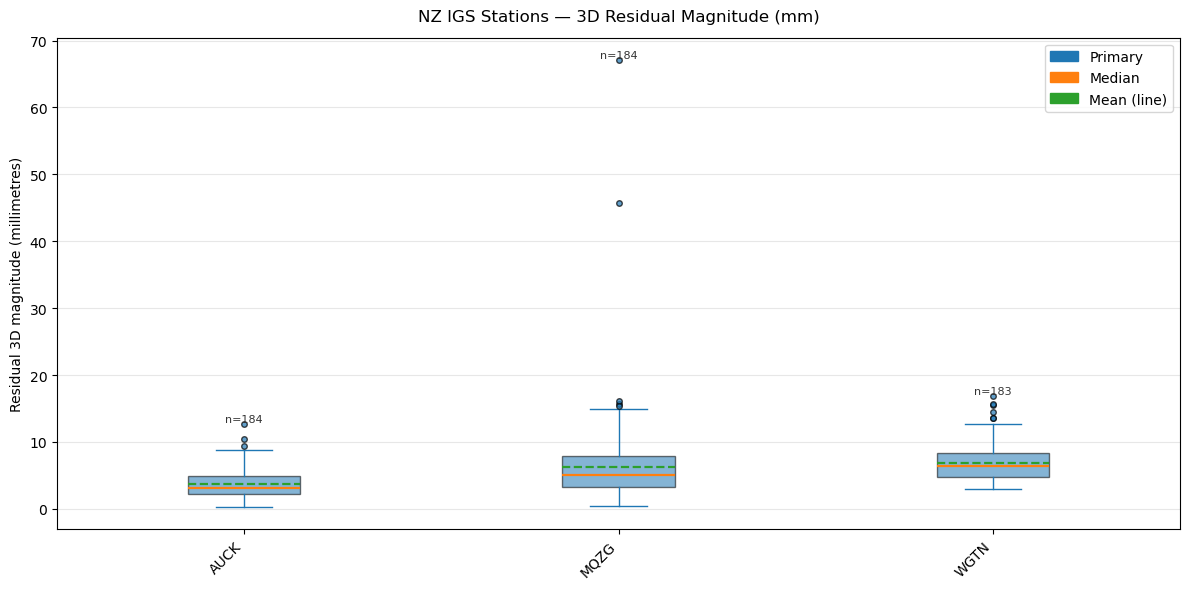

In [103]:

plot_nz_igs_boxplot(
    events_primary=NZ_EVENTS,   # built by Step X
    events_other=None,          # add other dataset later for comparison
    exclude_rejected=True,      # no 'R' tails present, so this is benign
    min_samples=3,
    out_dir=PLOT_DIR,
    filename="nz_igs_boxplot.png",
    title="NZ IGS Stations — 3D Residual Magnitude (mm)"
)


In [105]:
OUT_DIR = Path("exports")
OUT_DIR.mkdir(exist_ok=True)

def export_boxplot_raw(
    events_primary: pd.DataFrame,
    events_other: pd.DataFrame = None,
    *,
    exclude_rejected: bool = True,
    min_samples: int = 3,
):
    # Filter function consistent with your plotting step
    def _filter_ev(ev: pd.DataFrame) -> pd.DataFrame:
        df = ev.copy()
        df = df[df["status"].isin(["IW", "IA"])]
        if exclude_rejected and "tail" in df.columns:
            df = df[df["tail"] != "R"]
        return df

    df1 = _filter_ev(events_primary)
    # Keep only sites with at least min_samples
    site_counts1 = df1.groupby("site")["r_mag_mm"].count()
    keep_sites1 = set(site_counts1[site_counts1 >= min_samples].index)
    df1 = df1[df1["site"].isin(keep_sites1)].copy()
    df1["dataset"] = "Primary"

    if isinstance(events_other, pd.DataFrame) and not events_other.empty:
        df2 = _filter_ev(events_other)
        site_counts2 = df2.groupby("site")["r_mag_mm"].count()
        keep_sites2 = set(site_counts2[site_counts2 >= min_samples].index)
        # Align to overlapping sites (as in the plot)
        overlap = sorted(keep_sites1 & keep_sites2)
        df1 = df1[df1["site"].isin(overlap)].copy()
        df2 = df2[df2["site"].isin(overlap)].copy()
        df2["dataset"] = "Other"
        raw_out = pd.concat([df1, df2], ignore_index=True)
    else:
        raw_out = df1

    # Columns useful for checking & replotting
    cols = ["dataset", "file", "date", "site", "status", "tail", "r_mag_mm", "r1", "r2", "r3"]
    cols = [c for c in cols if c in raw_out.columns]
    raw_out = raw_out[cols].sort_values(["dataset", "site", "date"])

    # Write CSV
    raw_csv = OUT_DIR / "nz_boxplot_raw_residuals.csv"
    raw_out.to_csv(raw_csv, index=False)
    print("Saved:", raw_csv.resolve())

    return raw_out

# Example calls:
# Single dataset
raw_primary = export_boxplot_raw(NZ_EVENTS, events_other=None, exclude_rejected=True, min_samples=3)

# If you have a second solution dataframe (built like NZ_EVENTS)
# raw_both = export_boxplot_raw(NZ_EVENTS, NZ_EVENTS_OTHER, exclude_rejected=True, min_samples=3)

Saved: C:\Users\LHansen\OneDrive - Land Information New Zealand\2025\Python\Scripts\IGG_sites_check\exports\nz_boxplot_raw_residuals.csv
